## Описание проекта

### Источник данных

Датасет **Give Me Some Credit** — исторические данные о 150 000 заемщиках (в оригинале 250 000). Задача — предсказать вероятность финансовых трудностей (просрочка 90+ дней) в течение следующих 2 лет.

**Официальная метрика:** ROC-AUC

### Цель бизнеса

Снижение кредитных потерь при удержании доли рынка. Банк должен одобрять кредиты платежеспособным заемщикам и отказывать тем, кто допустит дефолт. С учетом материалов из интернет сервисов один пропущенный дефолт обходится в 10 раз дороже прибыли с одного хорошего клиента.

### Цель машинного обучения

Построить бинарный классификатор для оценки вероятности дефолта (просрочка 90+ дней за 2 года) по историческим данным. Основная метрика — ROC-AUC (согласно условиям соревнования), бизнес-метрика — прибыль при оптимальном пороге.

### Импортирование библиотек и модулей

In [1]:
# Библиотеки для осмотра и работы с данными
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Деактивация предупреждений при работе с библиотеками
import warnings
warnings.filterwarnings('ignore')

# Модули для предобработки и деления данных
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import OrdinalEncoder

from sklearn.isotonic import IsotonicRegression

# Модели машинного обучения
# Линейные модели
from sklearn.linear_model import LogisticRegression

# Деревья и ансамбли
from sklearn.ensemble import RandomForestClassifier

# Градиентный бустинг (основные фреймворки)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Метрики качества
from sklearn.metrics import (
    # Основные метрики
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    
    # Кривые и визуализация
    roc_curve,

    # Калибровка
    brier_score_loss, 
    log_loss,
    
    # Отчеты
    confusion_matrix
)

# Калибровка моделей
from sklearn.calibration import calibration_curve


# Мониторинг дрейфа данных (PSI)
def calculate_psi(expected, actual, buckets=10):
    """
    Population Stability Index
    PSI < 0.1: нет дрейфа
    0.1 <= PSI < 0.25: умеренный дрейф
    PSI >= 0.25: сильный дрейф
    """
    breakpoints = np.linspace(0, 1, buckets + 1)
    
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Замена нулей на маленькое число для избежания деления на ноль
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    psi_value = np.sum((expected_percents - actual_percents) * 
                       np.log(expected_percents / actual_percents))
    
    return psi_value

# Функция расчета бизнес-метрик (Profit)
def calculate_business_metrics(y_true, y_proba, threshold, 
                               gain_per_good=10000, loss_per_bad=100000):
    """
    Расчет прибыли при заданном пороге отсечения
    
    Parameters:
    -----------
    y_true : array-like
        Истинные метки (1 - дефолт, 0 - хороший)
    y_proba : array-like
        Предсказанные вероятности дефолта
    threshold : float
        Порог отсечения (если proba >= threshold -> отказ)
    gain_per_good : float
        Прибыль с одного хорошего клиента
    loss_per_bad : float
        Убыток с одного плохого клиента
    
    Returns:
    --------
    profit : float
        Общая прибыль
    approval_rate : float
        Доля одобренных заявок
    bad_rate : float
        Доля дефолтов среди одобренных
    """
    # Если вероятность дефолта выше порога -> ОТКАЗЫВАЕМ
    approved = y_proba < threshold
    
    # TP: одобрили хорошего (y_true == 0 и approved == True)
    tp = ((y_true == 0) & approved).sum()
    
    # FP: одобрили плохого (y_true == 1 и approved == True)
    fp = ((y_true == 1) & approved).sum()
    
    # Расчет метрик
    profit = (tp * gain_per_good) - (fp * loss_per_bad)
    approval_rate = approved.mean()
    
    # Bad rate среди одобренных (должен быть низким)
    bad_rate = fp / (tp + fp) if (tp + fp) > 0 else 0
    
    return profit, approval_rate, bad_rate

# Вывод информации о среде выполнения
import sys
import sklearn

print('Проверка библиотек и их версий:')
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"LightGBM version: {LGBMClassifier.__module__.split('.')[0]} " 
      f"{__import__('lightgbm').__version__}")
print(f"XGBoost version: {__import__('xgboost').__version__}")
print(f"CatBoost version: {__import__('catboost').__version__}")

Проверка библиотек и их версий:
Python version: 3.11.13
NumPy version: 1.26.4
Pandas version: 2.2.3
Scikit-learn version: 1.2.2
LightGBM version: lightgbm 4.6.0
XGBoost version: 2.0.3
CatBoost version: 1.2.8
SHAP version: 0.44.1


### Коснтанты

In [2]:
seed = 22
np.random.seed(seed)

## 1. Загрузка и осмотр данных

In [3]:
df = pd.read_csv('/kaggle/input/first-project/cs-training.csv')

print(f"Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов\n")
print(df.info(), '\n')
display(df.head())

display(df.describe().T)

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Количество': missing, 'Процент': missing_pct})
display(missing_df[missing_df['Количество'] > 0])

for col in df.columns:
    print(f"{col:<40} уникальных: {df[col].nunique():,}")

Размер датасета: 150,000 строк, 12 столбцов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPa

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


,Количество,Процент
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


Unnamed: 0                               уникальных: 150,000
SeriousDlqin2yrs                         уникальных: 2
RevolvingUtilizationOfUnsecuredLines     уникальных: 125,728
age                                      уникальных: 86
NumberOfTime30-59DaysPastDueNotWorse     уникальных: 16
DebtRatio                                уникальных: 114,194
MonthlyIncome                            уникальных: 13,594
NumberOfOpenCreditLinesAndLoans          уникальных: 58
NumberOfTimes90DaysLate                  уникальных: 19
NumberRealEstateLoansOrLines             уникальных: 28
NumberOfTime60-89DaysPastDueNotWorse     уникальных: 13
NumberOfDependents                       уникальных: 13


Целевая переменная:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Процент дефолтов: 6.68%


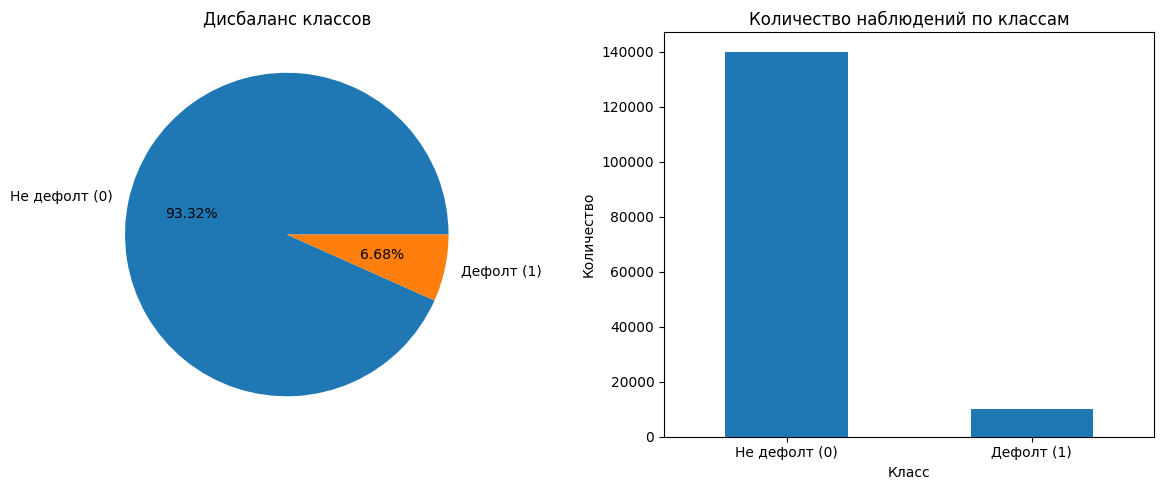

In [4]:
print("Целевая переменная:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nПроцент дефолтов: {df['SeriousDlqin2yrs'].mean():.2%}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['SeriousDlqin2yrs'].value_counts().plot.pie(
    autopct='%1.2f%%', 
    labels=['Не дефолт (0)', 'Дефолт (1)'],
    ax=axes[0]
)
axes[0].set_title('Дисбаланс классов')
axes[0].set_ylabel('')

df['SeriousDlqin2yrs'].value_counts().plot.bar(ax=axes[1])
axes[1].set_title('Количество наблюдений по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
axes[1].set_xticklabels(['Не дефолт (0)', 'Дефолт (1)'], rotation=0)

plt.tight_layout()
plt.show()

Анализ возраста:
age = 0: 1 строка(и)
age < 18: 1 (несовершеннолетние)
age > 90: 489 (старше 90 лет)

Дефолтность по возрастным группам:
            mean  count
age_group              
<25        11.17   3027
25-35      11.12  18458
35-45       8.81  29819
45-55       7.59  36690
55-65       4.58  33406
65+         2.41  28599


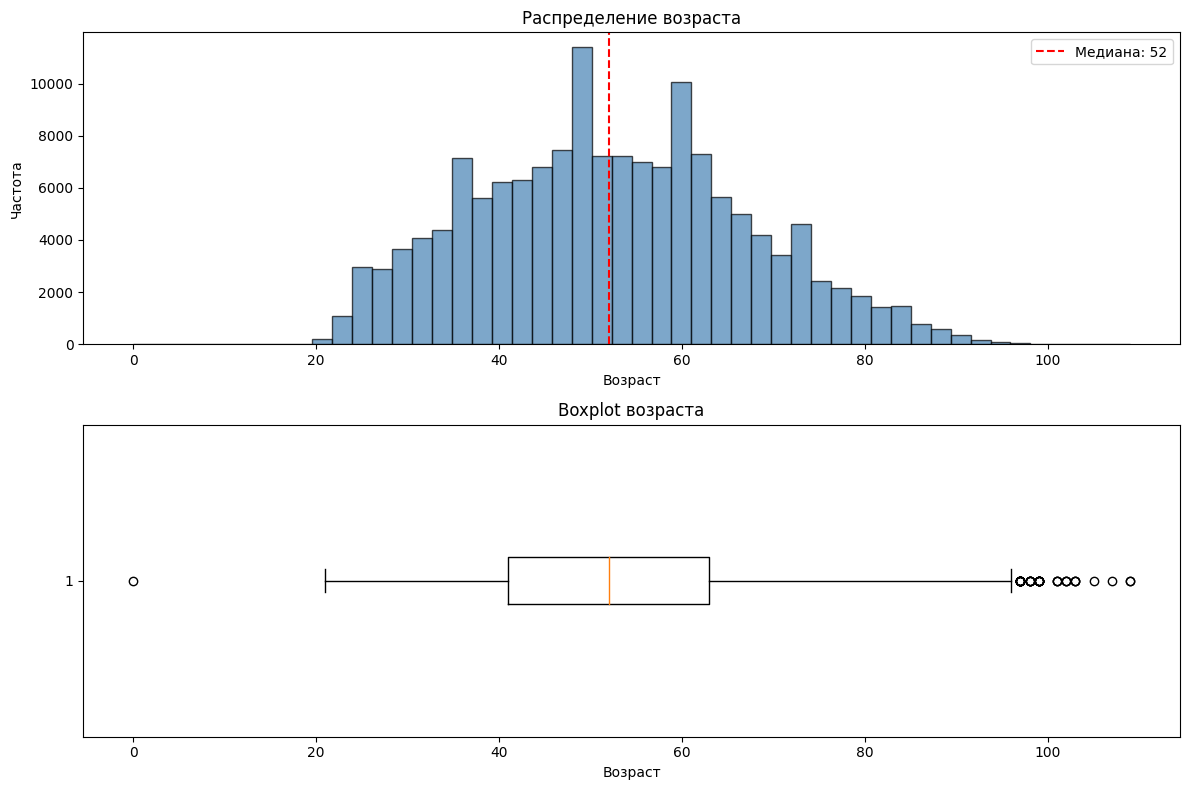

In [5]:
print("Анализ возраста:")
print(f"age = 0: {(df['age'] == 0).sum()} строка(и)")
print(f"age < 18: {(df['age'] < 18).sum()} (несовершеннолетние)")
print(f"age > 90: {(df['age'] > 90).sum()} (старше 90 лет)")

# Дефолтность по возрастным группам
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 120], 
                         labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])
print("\nДефолтность по возрастным группам:")
age_default = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
age_default['mean'] = age_default['mean'] * 100
print(age_default.round(2))

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].hist(df['age'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['age'].median(), color='red', linestyle='--', label=f"Медиана: {df['age'].median():.0f}")
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot(df['age'], vert=False)
axes[1].set_title('Boxplot возраста')
axes[1].set_xlabel('Возраст')

plt.tight_layout()
plt.show()

# Удаляем вспомогательный столбец
df.drop('age_group', axis=1, inplace=True)

Признак RevolvingUtilizationOfUnsecuredLines:
median: 0.1542

Анализ выбросов:
> 1.0: 3,321 (2.21%)
> 2.0: 371 (0.25%)
> 5.0: 254 (0.17%)

Дефолтность по группам utilization:
             mean  count
util_group              
0            2.09  22323
0-0.5        2.92  86389
0.5-1.0     15.28  37967
1.0-2.0     40.10   2950
>2.0        14.56    371


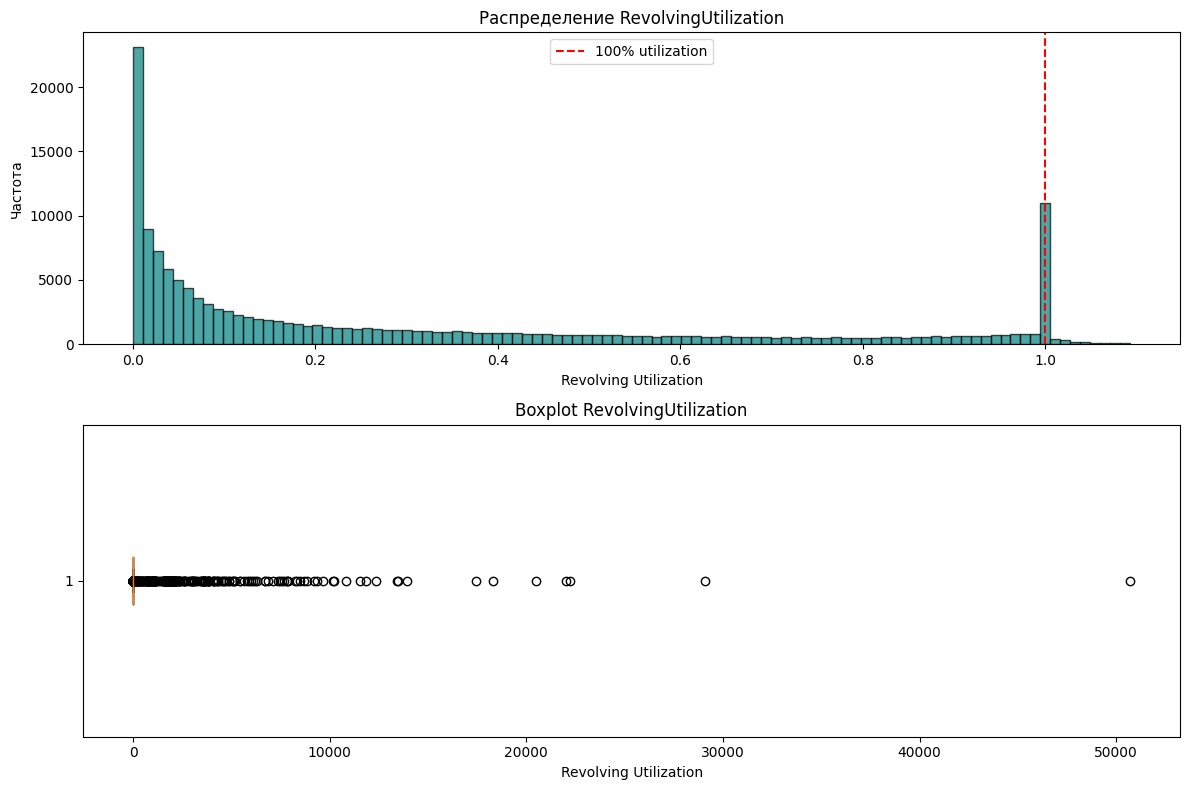

In [6]:
print("Признак RevolvingUtilizationOfUnsecuredLines:")
print(f"median: {df['RevolvingUtilizationOfUnsecuredLines'].median():.4f}")

print(f"\nАнализ выбросов:")
print(f"> 1.0: {(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum():,} ({df['RevolvingUtilizationOfUnsecuredLines'].gt(1).mean():.2%})")
print(f"> 2.0: {(df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum():,} ({df['RevolvingUtilizationOfUnsecuredLines'].gt(2).mean():.2%})")
print(f"> 5.0: {(df['RevolvingUtilizationOfUnsecuredLines'] > 5).sum():,} ({df['RevolvingUtilizationOfUnsecuredLines'].gt(5).mean():.2%})")

# Дефолтность по уровням utilization
df['util_group'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], 
                          bins=[-0.01, 0.01, 0.5, 1.0, 2.0, float('inf')],
                          labels=['0', '0-0.5', '0.5-1.0', '1.0-2.0', '>2.0'])
print("\nДефолтность по группам utilization:")
util_default = df.groupby('util_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
util_default['mean'] = util_default['mean'] * 100
print(util_default.round(2))

# Визуализация (только до 99 перцентиля для читаемости)
cap_99 = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].hist(df[df['RevolvingUtilizationOfUnsecuredLines'] <= cap_99]['RevolvingUtilizationOfUnsecuredLines'], 
             bins=100, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(1.0, color='red', linestyle='--', label='100% utilization')
axes[0].set_title(f'Распределение RevolvingUtilization')
axes[0].set_xlabel('Revolving Utilization')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot(df['RevolvingUtilizationOfUnsecuredLines'], vert=False)
axes[1].set_title('Boxplot RevolvingUtilization')
axes[1].set_xlabel('Revolving Utilization')

plt.tight_layout()
plt.show()

df.drop('util_group', axis=1, inplace=True)

Признак DebtRatio:
  median: 0.3665

Распределение DebtRatio по квантилям:
   50.0%: 0.3665
   75.0%: 0.8683
   90.0%: 1267.0000
   95.0%: 2449.0000
   99.0%: 4979.0400
   99.5%: 6186.0100
   99.9%: 10613.0740

Анализ экстремальных значений:
> 10: 28,877 (19.25%)
> 100: 24,380 (16.25%)
> 1000: 16,892 (11.26%)

Дефолтность по группам DebtRatio:
             mean  count
debt_group              
0-0.2        6.11  42289
0.2-0.5      5.97  51419
0.5-1.0      9.83  21155
1.0-2.0     13.17   4092
2-10         6.60   2168
10-100       4.43   4497
>100         5.78  24380

Анализ клиентов с DebtRatio > 100 (24380 чел.):
Средний доход: 1
Медианный доход: 0
Доход = 0: 1219
Доход = NaN: 22693


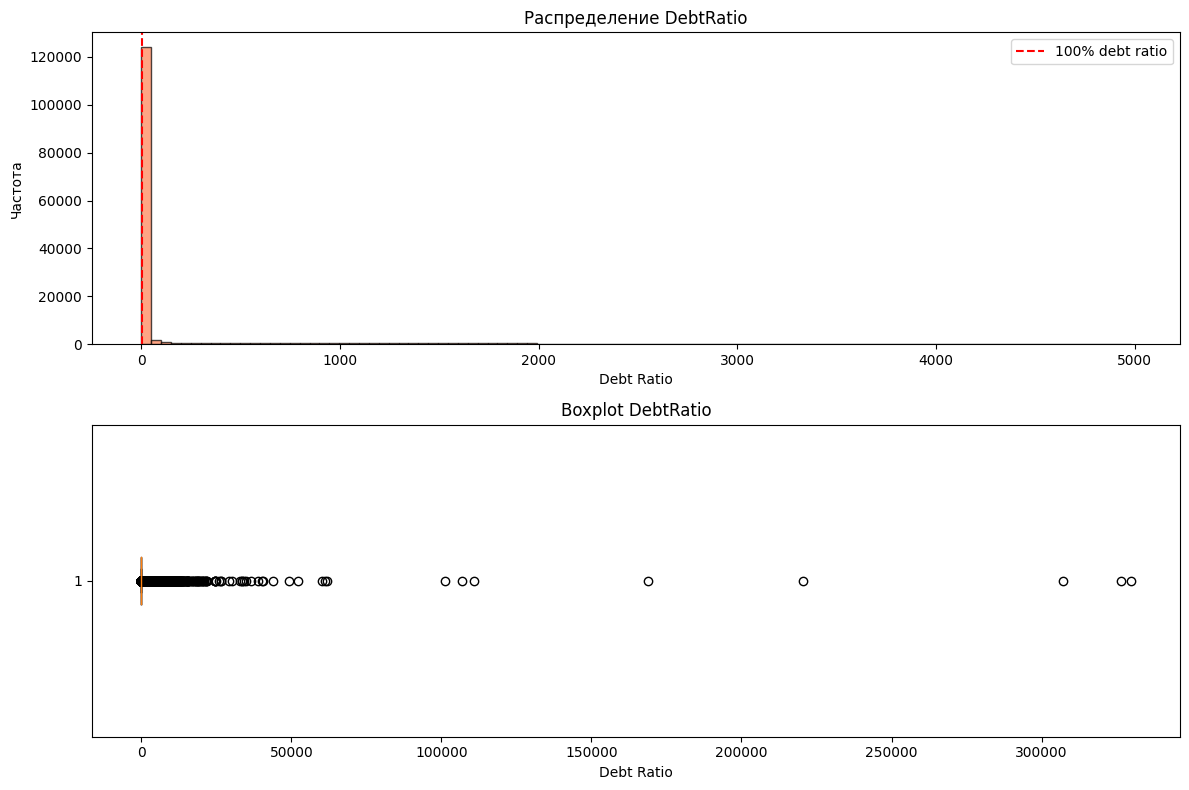

In [7]:
print("Признак DebtRatio:")
print(f"  median: {df['DebtRatio'].median():.4f}")

print(f"\nРаспределение DebtRatio по квантилям:")
for q in [0.5, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]:
    val = df['DebtRatio'].quantile(q)
    print(f"  {q*100:5.1f}%: {val:.4f}")

print(f"\nАнализ экстремальных значений:")
print(f"> 10: {(df['DebtRatio'] > 10).sum():,} ({df['DebtRatio'].gt(10).mean():.2%})")
print(f"> 100: {(df['DebtRatio'] > 100).sum():,} ({df['DebtRatio'].gt(100).mean():.2%})")
print(f"> 1000: {(df['DebtRatio'] > 1000).sum():,} ({df['DebtRatio'].gt(1000).mean():.2%})")

# Дефолтность по группам
df['debt_group'] = pd.cut(df['DebtRatio'], 
                          bins=[-0.01, 0.2, 0.5, 1.0, 2.0, 10, 100, float('inf')],
                          labels=['0-0.2', '0.2-0.5', '0.5-1.0', '1.0-2.0', '2-10', '10-100', '>100'])
print("\nДефолтность по группам DebtRatio:")
debt_default = df.groupby('debt_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
debt_default['mean'] = debt_default['mean'] * 100
print(debt_default.round(2))

# Анализ связи с доходом у экстремальных значений
high_debt = df[df['DebtRatio'] > 100]
print(f"\nАнализ клиентов с DebtRatio > 100 ({len(high_debt)} чел.):")
print(f"Средний доход: {high_debt['MonthlyIncome'].mean():.0f}")
print(f"Медианный доход: {high_debt['MonthlyIncome'].median():.0f}")
print(f"Доход = 0: {(high_debt['MonthlyIncome'] == 0).sum()}")
print(f"Доход = NaN: {high_debt['MonthlyIncome'].isna().sum()}")

# Визуализация (до 99 перцентиля)
cap_99 = df['DebtRatio'].quantile(0.99)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].hist(df[df['DebtRatio'] <= cap_99]['DebtRatio'], 
             bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(1.0, color='red', linestyle='--', label='100% debt ratio')
axes[0].set_title(f'Распределение DebtRatio')
axes[0].set_xlabel('Debt Ratio')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot(df['DebtRatio'], vert=False)
axes[1].set_title('Boxplot DebtRatio')
axes[1].set_xlabel('Debt Ratio')

plt.tight_layout()
plt.show()

Анализ признака MonthlyIncome:
Всего записей: 150,000
Пропусков (NaN): 29,731 (19.82%)
Значений = 0: 1,634
Значений > 0: 118,635

Дефолтность по статусу дохода:
Доход пропущен (NaN): 5.61%
Доход = 0: 4.04%
Доход > 0: 6.99%

Статистика для MonthlyIncome > 0:
min: 1
max: 3008750
median: 5437
mean: 6762
99 перцентиль: 25000


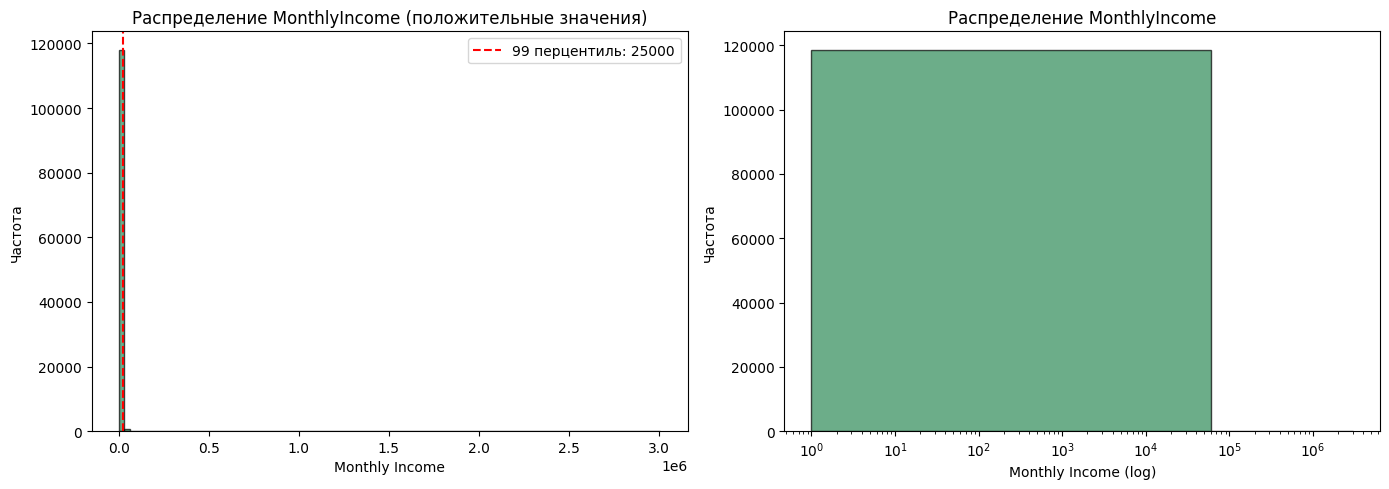

In [8]:
print("Анализ признака MonthlyIncome:")
print(f"Всего записей: {len(df):,}")
print(f"Пропусков (NaN): {df['MonthlyIncome'].isna().sum():,} ({df['MonthlyIncome'].isna().mean():.2%})")
print(f"Значений = 0: {(df['MonthlyIncome'] == 0).sum():,}")
print(f"Значений > 0: {(df['MonthlyIncome'] > 0).sum():,}")

print("\nДефолтность по статусу дохода:")
print(f"Доход пропущен (NaN): {df[df['MonthlyIncome'].isna()]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Доход = 0: {df[df['MonthlyIncome'] == 0]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Доход > 0: {df[df['MonthlyIncome'] > 0]['SeriousDlqin2yrs'].mean():.2%}")

# Статистика по положительным доходам
positive_income = df[df['MonthlyIncome'] > 0]['MonthlyIncome']
print(f"\nСтатистика для MonthlyIncome > 0:")
print(f"min: {positive_income.min():.0f}")
print(f"max: {positive_income.max():.0f}")
print(f"median: {positive_income.median():.0f}")
print(f"mean: {positive_income.mean():.0f}")
print(f"99 перцентиль: {positive_income.quantile(0.99):.0f}")

# Визуализация (до 99 перцентиля)
cap_99 = df[df['MonthlyIncome'] > 0]['MonthlyIncome'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['MonthlyIncome'] > 0]['MonthlyIncome'], 
             bins=100, edgecolor='black', alpha=0.7, color='seagreen')
axes[0].axvline(cap_99, color='red', linestyle='--', label=f'99 перцентиль: {cap_99:.0f}')
axes[0].set_title('Распределение MonthlyIncome (положительные значения)')
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Логарифмическая шкала для лучшей читаемости
axes[1].hist(df[df['MonthlyIncome'] > 0]['MonthlyIncome'], 
             bins=50, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_xscale('log')
axes[1].set_title('Распределение MonthlyIncome')
axes[1].set_xlabel('Monthly Income (log)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Признак NumberOfTime30-59DaysPastDueNotWorse
Уникальных значений: 16
min: 0, max: 98
median: 0.0000
>  0: 23,982 (15.99%) | Дефолтность: 20.79%
>  1:  7,949 ( 5.30%) | Дефолтность: 32.41%
>  3:  1,597 ( 1.06%) | Дефолтность: 46.27%
>  5:    508 ( 0.34%) | Дефолтность: 52.56%
> 10:    273 ( 0.18%) | Дефолтность: 54.95%


  Просрочка > 0, но target=0: 18,997
Признак NumberOfTime60-89DaysPastDueNotWorse
Уникальных значений: 13
min: 0, max: 98
median: 0.0000
>  0:  7,604 ( 5.07%) | Дефолтность: 36.43%
>  1:  1,873 ( 1.25%) | Дефолтность: 53.02%
>  3:    437 ( 0.29%) | Дефолтность: 57.67%
>  5:    298 ( 0.20%) | Дефолтность: 55.70%
> 10:    270 ( 0.18%) | Дефолтность: 54.81%


  Просрочка > 0, но target=0: 4,834
Признак NumberOfTimes90DaysLate
Уникальных значений: 19
min: 0, max: 98
median: 0.0000
>  0:  8,338 ( 5.56%) | Дефолтность: 41.64%
>  1:  3,095 ( 2.06%) | Дефолтность: 55.15%
>  3:    873 ( 0.58%) | Дефолтность: 62.54%
>  5:    451 ( 0.30%) | Дефолтность: 59.42%
> 10:    285 ( 0.19%

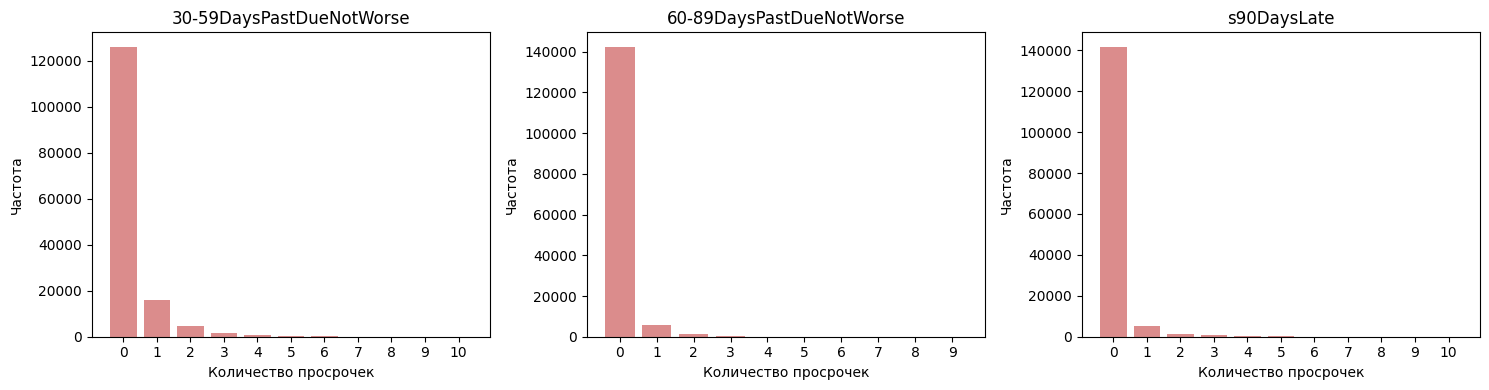

In [9]:
delay_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in delay_cols:
    print(f"Признак {col}")
    
    print(f"Уникальных значений: {df[col].nunique()}")
    print(f"min: {df[col].min()}, max: {df[col].max()}")
    print(f"median: {df[col].median():.4f}")
    
    for threshold in [0, 1, 3, 5, 10]:
        count = (df[col] > threshold).sum()
        pct = count / len(df) * 100
        default_rate = df[df[col] > threshold]['SeriousDlqin2yrs'].mean() * 100
        print(f"> {threshold:2d}: {count:6,} ({pct:5.2f}%) | Дефолтность: {default_rate:.2f}%")

    print()
    
    # Проверка логической ошибки: просрочка есть, но target=0
    bad_flag = (df[col] > 0) & (df['SeriousDlqin2yrs'] == 0)
    print(f"\n  Просрочка > 0, но target=0: {bad_flag.sum():,}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(delay_cols):
    # Считаем частоты значений
    value_counts = df[col].value_counts().sort_index()
    # Берем только значения до 10 для читаемости
    value_counts_filtered = value_counts[value_counts.index <= 10]
    
    axes[i].bar(value_counts_filtered.index.astype(str), value_counts_filtered.values, 
               color='indianred', alpha=0.7)
    axes[i].set_title(f'{col.split("NumberOfTime")[1]}')
    axes[i].set_xlabel('Количество просрочек')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Признак NumberOfOpenCreditLinesAndLoans
Уникальных значений: 58
median: 8.0

Дефолтность по количеству кредитных линий:
               mean  count
credit_group              
0             25.64   1888
1-3            9.30  20162
4-7            5.96  51399
8-11           5.53  41862
12-15          6.39  20863
15+            6.91  13826

Признак NumberRealEstateLoansOrLines
Уникальных значений: 28
median: 1.0

Дефолтность по количеству ипотек:
               mean  count
estate_group              
0              8.31  56188
1              5.25  52338
2              5.60  31522
3-5            7.63   9159
5+            17.91    793


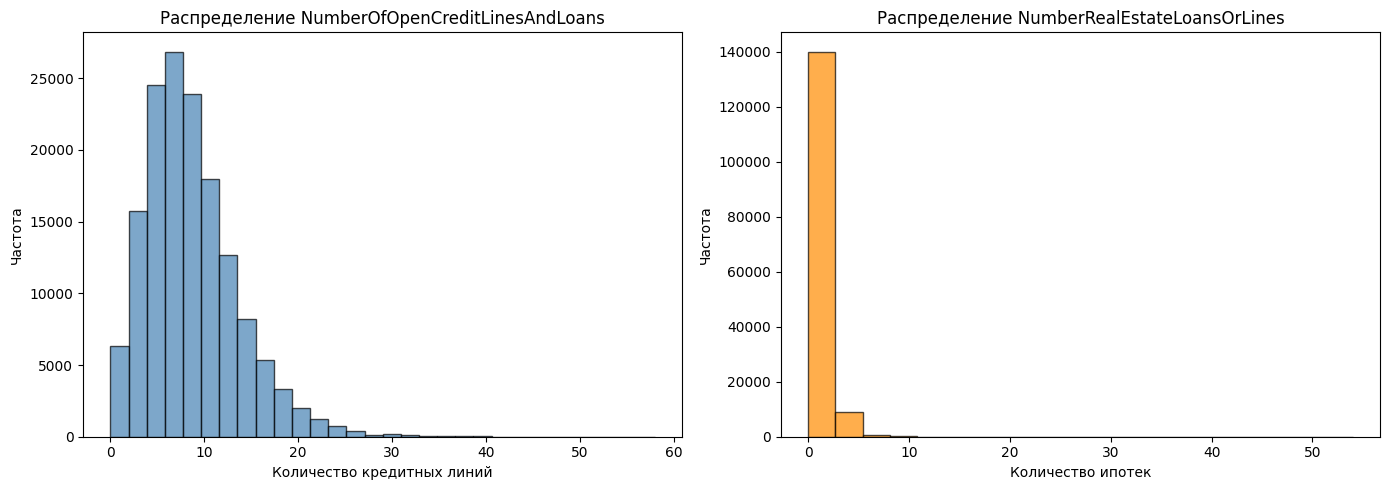

In [10]:
print("Признак NumberOfOpenCreditLinesAndLoans")
print(f"Уникальных значений: {df['NumberOfOpenCreditLinesAndLoans'].nunique()}")
print(f"median: {df['NumberOfOpenCreditLinesAndLoans'].median()}")

df['credit_group'] = pd.cut(df['NumberOfOpenCreditLinesAndLoans'], 
                            bins=[-1, 0, 3, 7, 11, 15, float('inf')],
                            labels=['0', '1-3', '4-7', '8-11', '12-15', '15+'])
print("\nДефолтность по количеству кредитных линий:")
credit_default = df.groupby('credit_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
credit_default['mean'] = credit_default['mean'] * 100
print(credit_default.round(2))

print("\nПризнак NumberRealEstateLoansOrLines")
print(f"Уникальных значений: {df['NumberRealEstateLoansOrLines'].nunique()}")
print(f"median: {df['NumberRealEstateLoansOrLines'].median()}")

df['estate_group'] = pd.cut(df['NumberRealEstateLoansOrLines'], 
                            bins=[-1, 0, 1, 2, 5, float('inf')],
                            labels=['0', '1', '2', '3-5', '5+'])
print("\nДефолтность по количеству ипотек:")
estate_default = df.groupby('estate_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
estate_default['mean'] = estate_default['mean'] * 100
print(estate_default.round(2))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['NumberOfOpenCreditLinesAndLoans'], bins=30, 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Распределение NumberOfOpenCreditLinesAndLoans')
axes[0].set_xlabel('Количество кредитных линий')
axes[0].set_ylabel('Частота')

axes[1].hist(df['NumberRealEstateLoansOrLines'], bins=20, 
             edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_title('Распределение NumberRealEstateLoansOrLines')
axes[1].set_xlabel('Количество ипотек')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Удаляем вспомогательные столбцы
df.drop(['credit_group', 'estate_group'], axis=1, inplace=True)


In [11]:
print("Признак NumberOfDependents:")
print(f"Пропусков (NaN): {df['NumberOfDependents'].isna().sum():,} ({df['NumberOfDependents'].isna().mean():.2%})")
print(f"Уникальных значений: {df['NumberOfDependents'].nunique()}")

print("\nДефолтность по статусу:")
print(f"Значение пропущено: {df[df['NumberOfDependents'].isna()]['SeriousDlqin2yrs'].mean():.2%}")
print(f"Значение известно: {df[df['NumberOfDependents'].notna()]['SeriousDlqin2yrs'].mean():.2%}")

print("\nРаспределение известных значений:")
print(df[df['NumberOfDependents'].notna()]['NumberOfDependents'].value_counts().sort_index().head(10))

# Дефолтность по количеству иждивенцев
df['dep_group'] = df['NumberOfDependents'].fillna(-1)
df['dep_group'] = pd.cut(df['dep_group'], 
                         bins=[-2, -0.5, 0.5, 1.5, 2.5, 5, float('inf')],
                         labels=['NaN', '0', '1', '2', '3-5', '5+'])
print("\nДефолтность по группам:")
dep_default = df.groupby('dep_group', observed=True)['SeriousDlqin2yrs'].agg(['mean', 'count'])
dep_default['mean'] = dep_default['mean'] * 100
print(dep_default.round(2))

# Связь с возрастом
print(f"\nСредний возраст:")
print(f"При пропуске dependents: {df[df['NumberOfDependents'].isna()]['age'].mean():.1f} лет")
print(f"При известном dependents: {df[df['NumberOfDependents'].notna()]['age'].mean():.1f} лет")

df.drop('dep_group', axis=1, inplace=True)

Признак NumberOfDependents:
Пропусков (NaN): 3,924 (2.62%)
Уникальных значений: 13

Дефолтность по статусу:
Значение пропущено: 4.56%
Значение известно: 6.74%

Распределение известных значений:
NumberOfDependents
0.0    86902
1.0    26316
2.0    19522
3.0     9483
4.0     2862
5.0      746
6.0      158
7.0       51
8.0       24
9.0        5
Name: count, dtype: int64

Дефолтность по группам:
            mean  count
dep_group              
NaN         4.56   3924
0           5.86  86902
1           7.35  26316
2           8.11  19522
3-5         9.18  13091
5+         12.65    245

Средний возраст:
При пропуске dependents: 59.6 лет
При известном dependents: 52.1 лет


### 1. Сводка по загрузке и осмотру данных

### 1.1. Структура и размер данных
Датасет содержит **150 000** записей о заемщиках и **12** признаков (11 независимых и 1 целевая переменная).  
Общий объем пропусков в данных составил **22.44%** (по `MonthlyIncome` и `NumberOfDependents` вместе), однако визуальный осмотр выявил, что часть пропусков закодирована нулями в ряде финансовых признаков.

**Схема признаков:**
| Признак | Тип | Описание |
|---|---|---|
| `Unnamed: 0` | int | Номер по порядку (технический индекс) |
| `SeriousDlqin2yrs` (Target) | int | **1** - просрочка, **0** - нет просрочки |
| `RevolvingUtilizationOfUnsecuredLines` | float | Общий баланс по кредитным картам / общий лимит |
| `age` | int | Возраст заемщика |
| `NumberOfTime30-59DaysPastDueNotWorse` | int | Кол-во просрочек 30-59 дней за последние 2 года |
| `DebtRatio` | float | Ежемесячные платежи / ежемесячный доход |
| `MonthlyIncome` | float | Ежемесячный доход |
| `NumberOfOpenCreditLinesAndLoans` | int | Кол-во открытых кредитных линий |
| `NumberOfTimes90DaysLate` | int | Кол-во просрочек 90+ дней |
| `NumberRealEstateLoansOrLines` | int | Кол-во ипотек / кредитов под залог недвижимости |
| `NumberOfTime60-89DaysPastDueNotWorse` | int | Кол-во просрочек 60-89 дней за последние 2 года |
| `NumberOfDependents` | float | Кол-во иждивенцев |

### 1.2. Анализ целевой переменной (Target)
**Дисбаланс классов:** Встречаемость дефолтов (`SeriousDlqin2yrs = 1`) составляет **6.68%** (10'026 из 150'000).  
Это **сильный дисбаланс**.

**Вывод по дисбалансу:**
- Accuracy бесполезна (модель, предсказывающая всем 0, даст точность 93.32%).
- Основной фокус на метриках: **ROC-AUC**, **PR-AUC** и **Функция прибыли (Profit)**.
- При разбиении выборки обязательно использование **стратификации**.

### 1.3. Специфические аномалии
В ходе первичного осмотра выявлены критические особенности, требующие обработки на следующих этапах:

1. **Некорректные нули и пропуски:**
   - `MonthlyIncome`: обнаружено **29 731** пропусков (NaN) и **1 634** записей со значением `0`. Суммарно **20.91%** данных требуют обработки.  
     Анализ показал, что дефолтность клиентов с отсутствующим доходом **сильно зависит от наличия просрочек**:
       - Без просрочек: NaN доход → дефолтность **1.91%**, Zero доход → **1.80%**
       - С просрочками: NaN доход → дефолтность **24.24%**, Zero доход → **16.87%**
     *Что делаю:*  
       - Создаю бинарный индикатор `missing_income` (1 если доход NaN или 0).  
       - Для клиентов **без просрочек** заполню пропуски **медианой дохода хороших клиентов** (доход типичного заемщика, который просто не указал данные).  
       - Для клиентов **с просрочками** заполню пропуски **нулем** (реальный сигнал отсутствия дохода у проблемных заемщиков).

   - `NumberOfDependents`: обнаружено **3 924** пропусков (NaN). Значения `0` (86'902 записи) являются валидными (отсутствие иждивенцев).  
     Анализ выявил связь пропусков с возрастом: средний возраст клиентов с пропуском — **59.6 лет** против **52.1 лет** у остальных. 
     *Что делаю:*  
       - Создаю бинарный индикатор `missing_dependents`.  
       - Заполняю пропуски **медианой по возрастным группам** (у пенсионеров иждивенцев обычно нет).

2. **Физически невозможные значения:**
   - `age`: присутствует **1** запись с возрастом `0`. *Решение: удаление строки как технического артефакта.*
   - `age >= 90`: **687** клиентов (0.46%). Дефолтность этой группы — **2.04%** (ниже среднего). Признаки (доход, DebtRatio, просрочки) выглядят реалистично. *Оставлю так как есть, можно будет объединить в группу 65+.*
   - `RevolvingUtilizationOfUnsecuredLines`: **2.21%** значений (3'321 запись) превышают `1.0` (100% utilization). Скорее всего это не ошибка, а штрафы, которые характерны для рискованных заемщиков (дефолтность 40.1% в диапазоне 1.0-2.0). *Не будем удалять, заменим значениями 99 перцентиля.*
  - `DebtRatio`: **19.25%** значений превышают `1.0`, с выбросами до **329 664**. 
  Анализ показал, что значения > 2.0 — артефакт деления на околонулевой доход (у 93% таких клиентов доход пропущен или равен 0). 

3. **Есть ли временные отрезки в данных?:**
   - В данных отсутствуют поля даты или ID клиента, скорее всего данные замешаны и нет возможности отследить время их формирования.

### 1.4. Дальнейший пайплайн обработки

1. **Удаление технических столбцов и артефактов:**
   - Удалить столбец `Unnamed: 0`.
   - Удалить строку с `age == 0`.

2. **Работа с дубликатами** — проверка на полные дубликаты строк.

3. **Создание бинарных индикаторов:**
   - `missing_income` = 1, если `MonthlyIncome` is NaN или равен 0.
   - `missing_dependents` = 1, если `NumberOfDependents` is NaN.

4. **Заполнение пропусков:**
   - `MonthlyIncome`:
     - Для клиентов **без просрочек** — медиана дохода по группе `HAS_DELINQUENCY = 0`.
     - Для клиентов **с просрочками** — значение `0` (отсутствие дохода как фактор риска).
   - `NumberOfDependents` — медиана по возрастным группам (учитывая, что пропуски характерны для старших возрастов).

5. **Винзоризация выбросов:**
   - `RevolvingUtilizationOfUnsecuredLines` — каппинг на 99 перцентиле.
   - `DebtRatio` — каппинг на 98 перцентиле.

## 2. Предобработка данных

In [12]:
# Удаляю Unnamed: 0
df.drop('Unnamed: 0', axis=1, inplace=True)

# Удаляю строку с age == 0
df = df[df['age'] != 0]

# Проверка на дубликаты
print(f"Полных дубликатов: {df.duplicated().sum()}")


Полных дубликатов: 609


In [13]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} столбцов\n")

Размер: 149,390 строк, 12 столбцов



In [14]:
# missing_income = 1, если MonthlyIncome is NaN или равен 0.
df['missing_income'] = ((df['MonthlyIncome'].isna()) | (df['MonthlyIncome'] == 0)).astype(int)

# missing_dependents = 1, если иждивенцы пропущены
df['missing_dependents'] = df['NumberOfDependents'].isna().astype(int)

print(f"missing_income: {df['missing_income'].sum():,} клиентов")
print(f"missing_dependents: {df['missing_dependents'].sum():,} клиентов")
display(df.head())

missing_income: 30,837 клиентов
missing_dependents: 3,828 клиентов


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,debt_group,missing_income,missing_dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0.5-1.0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0-0.2,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0-0.2,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0-0.2,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0-0.2,0,0


In [15]:
# Временный столюец просрочек
df['has_delq'] = (
    (df['NumberOfTime30-59DaysPastDueNotWorse'] > 0) |
    (df['NumberOfTime60-89DaysPastDueNotWorse'] > 0) |
    (df['NumberOfTimes90DaysLate'] > 0)
).astype(int)

# Временный столбец возрастных групп
df['age_grp'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 120])

# Рассчет медианы для клиентов без просрочек и дохода больше 0
median_income = df.loc[(df['has_delq'] == 0) & (df['MonthlyIncome'] > 0), 'MonthlyIncome'].median()

# Замена значений 
mask_good = (df['has_delq'] == 0) & (df['missing_income'] == 1)
df.loc[mask_good, 'MonthlyIncome'] = median_income
print(f"Без просрочек: {mask_good.sum():,} клиентов")
mask_bad = (df['has_delq'] == 1) & (df['missing_income'] == 1)
df.loc[mask_bad, 'MonthlyIncome'] = 0
print(f"С просрочками: {mask_bad.sum():,} клиентов")

# Удаляем временные столбцы
df.drop(['has_delq', 'age_grp'], axis=1, inplace=True)

print(f"Пропусков в MonthlyIncome: {df['MonthlyIncome'].isna().sum()}")

Без просрочек: 25,722 клиентов
С просрочками: 5,115 клиентов
Пропусков в MonthlyIncome: 0


In [16]:
# Медиана по всему датасету
median_dep = df['NumberOfDependents'].median()

# Заполняем пропуски
df['NumberOfDependents'].fillna(median_dep, inplace=True)

print(f"Пропусков заполнено: {df['missing_dependents'].sum():,}")
print(f"Значение медианы: {median_dep:.0f}")
print(f"Пропусков осталось: {df['NumberOfDependents'].isna().sum()}")

Пропусков заполнено: 3,828
Значение медианы: 0
Пропусков осталось: 0


In [17]:
# Обработка выбросов
# RevolvingUtilizationOfUnsecuredLines — 99 перцентиль
cap_99 = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap_99)

# DebtRatio — 2.0
cap_debt = 2.0
count_above = (df['DebtRatio'] > cap_debt).sum()
df['DebtRatio'] = df['DebtRatio'].clip(upper=cap_debt)

In [18]:
# Проверим данные
print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"Пропусков: {df.isna().sum().sum()}")
print(f"Дефолтов: {df['SeriousDlqin2yrs'].mean():.2%}")

Размер: 149,390 строк, 14 столбцов
Пропусков: 0
Дефолтов: 6.70%


### 2. Результат предобработки

- Размер датасета: **149'390** строк (удалена 1 строка с age=0 и явные дубликаты - 609)
- Пропусков: **0**
- Дефолтов: **6.70%** (было 6.68%, изменение в пределах погрешности)
- Добавлено 2 признака: `missing_income`, `missing_dependents`
- Удалены пропуски: `RevolvingUtilizationOfUnsecuredLines` (99 перцентиль), `DebtRatio` (cap=2.0)

## 3. Feature engineering, WOE и Information Value (IV)

In [19]:
# Feature engineering 

# Признак 1. Сумма всех просрочек
df['delinquency_total'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] + 
    df['NumberOfTime60-89DaysPastDueNotWorse'] + 
    df['NumberOfTimes90DaysLate']
)

# Признак 2. Доход на иждивенца
df['income_per_dependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Признак 3. Кредитная активность (линий на год возраста)
df['credit_per_age'] = df['NumberOfOpenCreditLinesAndLoans'] / (df['age'] + 1)


# Признак 4. Возрастные группы (строковые)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+']
).astype(str)

# Признак 5. Признак наличия любой просрочки
df['any_delinquency'] = (df['delinquency_total'] > 0).astype(int)

In [20]:
new_features = [
    'delinquency_total',
    'income_per_dependent', 
    'credit_per_age',
    'age_group',
    'any_delinquency'
]

display(df[new_features].head())

print(f"Пропуски в новых признаках:")
for col in new_features:
    nulls = df[col].isna().sum()
    if nulls > 0:
        print(f"{col}: {nulls}")
    else:
        print(f"{col}: 0")

print(f"\nТекущий размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов")

,delinquency_total,income_per_dependent,credit_per_age,age_group,any_delinquency
0,2,3040.0,0.282609,35-45,1
1,0,1300.0,0.097561,35-45,0
2,2,3042.0,0.051282,35-45,1
3,0,3300.0,0.161290,25-35,0
4,1,63588.0,0.140000,45-55,1


Пропуски в новых признаках:
delinquency_total: 0
income_per_dependent: 0
credit_per_age: 0
age_group: 0
any_delinquency: 0

Текущий размер датасета: 149,390 строк, 19 столбцов


In [21]:
def calculate_woe_iv(df, feature, target, bins=10):
    data = df[[feature, target]].copy()
    
    # Для строковых/категориальных признаков
    if data[feature].dtype == 'object' or data[feature].dtype == 'string' or feature in ['UTILIZATION_CAT', 'AGE_GROUP']:
        # Каждая категория — отдельный бин
        data['bin'] = data[feature].astype(str)
        
    # Особые бины для просрочек
    elif feature in ['NumberOfTime30-59DaysPastDueNotWorse',
                     'NumberOfTime60-89DaysPastDueNotWorse',
                     'NumberOfTimes90DaysLate',
                     'DELINQUENCY_TOTAL']:
        bin_edges = [-np.inf, 0.5, 1.5, 2.5, np.inf]
        data['bin'] = pd.cut(data[feature], bins=bin_edges, include_lowest=True)
        
    # Бинарные признаки
    elif data[feature].nunique() <= 2:
        data['bin'] = data[feature]
        
    # Обычные числовые
    else:
        try:
            bin_edges = pd.qcut(data[feature], q=bins, duplicates='drop', retbins=True)[1]
            bin_edges = [-np.inf] + list(bin_edges[1:-1]) + [np.inf]
        except:
            bin_edges = np.linspace(data[feature].min(), data[feature].max(), bins+1)
            bin_edges = [-np.inf] + list(bin_edges[1:-1]) + [np.inf]
        data['bin'] = pd.cut(data[feature], bins=bin_edges, include_lowest=True)
    
    grouped = data.groupby('bin', observed=True)[target].agg(['count', 'sum'])
    grouped['good'] = grouped['count'] - grouped['sum']
    grouped['bad'] = grouped['sum']
    
    total_bad = grouped['bad'].sum()
    total_good = grouped['good'].sum()
    
    grouped['dist_bad'] = grouped['bad'] / total_bad
    grouped['dist_good'] = grouped['good'] / total_good
    grouped['woe'] = np.log((grouped['dist_bad'] + 0.0001) / (grouped['dist_good'] + 0.0001))
    grouped['iv_bin'] = (grouped['dist_bad'] - grouped['dist_good']) * grouped['woe']
    
    iv = grouped['iv_bin'].sum()
    mapping = {str(k): v for k, v in grouped['woe'].to_dict().items()}
    
    return grouped, iv, mapping

In [22]:
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'missing_income',
    'missing_dependents',
    'delinquency_total',
    'income_per_dependent', 
    'credit_per_age',
    'age_group',
    'any_delinquency'
]

target = 'SeriousDlqin2yrs'

In [23]:
# Расчет IV для всех признаков

iv_results = {}
woe_mappings = {}

for col in feature_cols:
    if col in ['age_group', 'any_delinquency']:
        bins = 2  
    else:
        bins = 10
    
    _, iv, mapping = calculate_woe_iv(df, col, target, bins=bins)
    iv_results[col] = iv
    woe_mappings[col] = mapping

iv_table = pd.DataFrame({
    'feature': list(iv_results.keys()),
    'IV': list(iv_results.values())
}).sort_values('IV', ascending=False)

iv_table['Predictive_Power'] = pd.cut(
    iv_table['IV'], 
    bins=[-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels=['Unpredictive', 'Weak', 'Medium', 'Strong', 'Suspicious']
)

print("\nInformation Value (с новыми признаками):")
print(iv_table.to_string(index=False))


Information Value (с новыми признаками):
                             feature       IV Predictive_Power
                     any_delinquency 1.172556       Suspicious
RevolvingUtilizationOfUnsecuredLines 1.117670       Suspicious
                   delinquency_total 1.048320       Suspicious
             NumberOfTimes90DaysLate 0.875101       Suspicious
NumberOfTime30-59DaysPastDueNotWorse 0.752075       Suspicious
NumberOfTime60-89DaysPastDueNotWorse 0.597146       Suspicious
                income_per_dependent 0.326902           Strong
                       MonthlyIncome 0.268827           Medium
                                 age 0.258068           Medium
                           age_group 0.250112           Medium
     NumberOfOpenCreditLinesAndLoans 0.070919             Weak
                      credit_per_age 0.053718             Weak
                           DebtRatio 0.025222             Weak
                  NumberOfDependents 0.024603             Weak
        Numbe

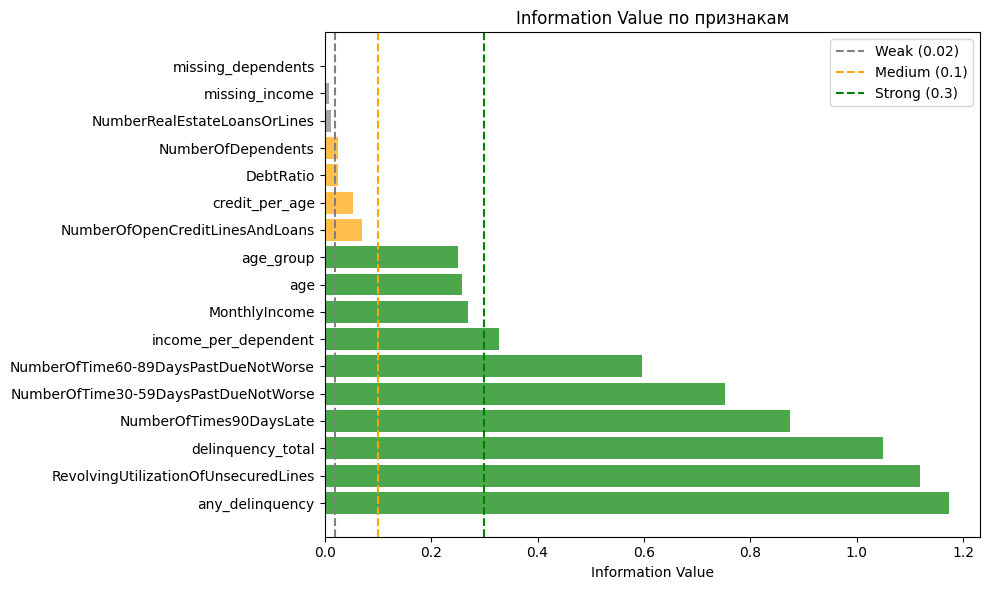

In [24]:
# Визуализация IV

plt.figure(figsize=(10, 6))
colors = ['green' if iv > 0.1 else 'orange' if iv > 0.02 else 'gray' for iv in iv_table['IV']]
plt.barh(iv_table['feature'], iv_table['IV'], color=colors, alpha=0.7)
plt.axvline(0.02, color='gray', linestyle='--', label='Weak (0.02)')
plt.axvline(0.1, color='orange', linestyle='--', label='Medium (0.1)')
plt.axvline(0.3, color='green', linestyle='--', label='Strong (0.3)')
plt.xlabel('Information Value')
plt.title('Information Value по признакам')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Отбор признаков с IV > 0.02

selected_features = iv_table[iv_table['IV'] > 0.02]['feature'].tolist()

print(f"\nОтобрано признаков: {len(selected_features)}")

X_woe = pd.DataFrame(index=df.index)

for col in selected_features:
    # Определяем бины
    if col in ['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate',
               'DELINQUENCY_TOTAL']:
        bin_edges = [-np.inf, 0.5, 1.5, 2.5, np.inf]
    elif col in ['age_group', 'any_delinquency']:
        # Категориальные — используем уникальные значения
        bin_edges = None
    else:
        try:
            bin_edges = pd.qcut(df[col], q=10, duplicates='drop', retbins=True)[1]
            bin_edges = [-np.inf] + list(bin_edges[1:-1]) + [np.inf]
        except:
            bin_edges = np.linspace(df[col].min(), df[col].max(), 11)
            bin_edges = [-np.inf] + list(bin_edges[1:-1]) + [np.inf]
    
    if bin_edges is not None:
        binned = pd.cut(df[col], bins=bin_edges, include_lowest=True)
    else:
        binned = df[col]
    
    X_woe[col + '_woe'] = binned.astype(str).map(woe_mappings[col]).fillna(0).astype(float)

y = df[target]

print(f"\nWOE-датасет: {X_woe.shape}")
display(X_woe.head())


Отобрано признаков: 14

WOE-датасет: (149390, 14)


,any_delinquency_woe,RevolvingUtilizationOfUnsecuredLines_woe,delinquency_total_woe,NumberOfTimes90DaysLate_woe,NumberOfTime30-59DaysPastDueNotWorse_woe,NumberOfTime60-89DaysPastDueNotWorse_woe,income_per_dependent_woe,MonthlyIncome_woe,age_woe,age_group_woe,NumberOfOpenCreditLinesAndLoans_woe,credit_per_age_woe,DebtRatio_woe,NumberOfDependents_woe
0,1.383403,1.005075,2.036166,-0.388907,1.610882,-0.287396,-0.015908,-0.359265,0.211460,0.297790,-0.044044,0.086143,0.116461,0.206725
1,-0.936738,1.005075,-0.561299,-0.388907,-0.540746,-0.287396,0.439774,0.402685,0.274636,0.297790,-0.044947,-0.228363,0.026544,-0.087773
2,1.383403,0.292131,2.036166,1.954289,0.900571,-0.287396,-0.015908,0.402685,0.391195,0.297790,0.531512,0.452232,0.026544,-0.087773
3,-0.936738,-0.685803,-0.561299,-0.388907,-0.540746,-0.287396,-0.015908,0.272124,0.587209,0.556486,-0.058832,-0.132643,0.026544,-0.087773
4,1.383403,1.005075,-0.561299,-0.388907,0.900571,-0.287396,-0.501342,-0.422695,0.151819,0.135058,-0.192685,-0.190615,-0.210725,-0.087773


### Итоги Feature Engineering, WOE и Information Value

На основе бизнес-логики и EDA созданы новые признаки для усиления предсказательной силы модели.

### Созданные признаки

| Признак | Формула | Логика |
|---|---|---|
| `delinquency_total` | Σ всех просрочек | Суммарная тяжесть просрочек |
| `income_per_dependent` | MonthlyIncome / (NumberOfDependents + 1) | Доход на члена семьи |
| `credit_per_age` | OpenCreditLines / (age + 1) | Кредитная активность с учетом возраста |
| `age_group` | Возрастные группы | <25, 25-35, 35-45, 45-55, 55-65, 65+ |
| `any_delinquency` | DELINQUENCY_TOTAL > 0 | Флаг наличия любых просрочек |

### Результаты WOE с новыми признаками

**Отобрано 14 признаков с IV > 0.02:**

| Признак | IV | Сила | Тип |
|---|---|---|---|
| `any_delinquency` | **1.17** | Suspicious | Новый |
| `RevolvingUtilizationOfUnsecuredLines` | 1.12 | Suspicious | Исходный |
| `delinquency_total` | **1.05** | Suspicious | Новый |
| `NumberOfTimes90DaysLate` | 0.88 | Suspicious | Исходный |
| `NumberOfTime30-59DaysPastDueNotWorse` | 0.75 | Suspicious | Исходный |
| `NumberOfTime60-89DaysPastDueNotWorse` | 0.60 | Suspicious | Исходный |
| `income_per_dependent` | **0.33** | Strong | Новый |
| `MonthlyIncome` | 0.27 | Medium | Исходный |
| `age` | 0.26 | Medium | Исходный |
| `age_group` | **0.25** | Medium | Новый |
| `NumberOfOpenCreditLinesAndLoans` | 0.07 | Weak | Исходный |
| `credit_per_age` | **0.05** | Weak | Новый |
| `DebtRatio` | 0.03 | Weak | Исходный |
| `NumberOfDependents` | 0.02 | Weak | Исходный |

### Выводы

- **Лучший новый признак:** `any_delinquency` (IV = 1.17) — простой бинарный признак просрочки оказался сильнее, чем отдельные счетчики.
- **Сумма просрочек** (`delinquency_total`, IV = 1.05) также вошла в топ.
- **Доход на иждивенца** (`income_per_dependent`, IV = 0.33) показал себя лучше, чем абсолютный доход.
- **Возрастная группа** (`age_group`, IV = 0.25) имеет схожую силу с непрерывным возрастом — можно оставить оба.

**Итоговый набор:** 14 WOE-признаков для обучения моделей.

## 4. Получение выборок

In [26]:
# Разделение данных на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_woe, 
    y, 
    test_size=0.2, 
    random_state=seed, 
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} строк ({X_train.shape[0]/len(X_woe):.0%})")
print(f"Test:  {X_test.shape[0]:,} строк ({X_test.shape[0]/len(X_woe):.0%})")

print(f"\nДефолтов в train: {y_train.mean():.2%}")
print(f"Дефолтов в test:  {y_test.mean():.2%}")
print(f"Дефолтов всего:   {y.mean():.2%}")

print(f"\nРазмеры:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Train: 119,512 строк (80%)
Test:  29,878 строк (20%)

Дефолтов в train: 6.70%
Дефолтов в test:  6.70%
Дефолтов всего:   6.70%

Размеры:
X_train: (119512, 14)
X_test:  (29878, 14)
y_train: (119512,)
y_test:  (29878,)


## 5. Первые модели


 Метрики Logistic Regression:
--------------------------------------------------
Train ROC-AUC:  0.8577
Test ROC-AUC:   0.8570
Test PR-AUC:    0.3860
Test Recall:    0.7383
Test Precision: 0.2175

Топ-5 важных признаков:
                                 feature  coefficient
                      credit_per_age_woe     0.846473
                           DebtRatio_woe     0.769689
RevolvingUtilizationOfUnsecuredLines_woe     0.667049
                     any_delinquency_woe     0.367902
                           age_group_woe     0.365007

Топ-5 анти-признаков (снижают риск):
                                 feature  coefficient
NumberOfTime30-59DaysPastDueNotWorse_woe     0.106589
                income_per_dependent_woe     0.101692
                                 age_woe     0.082741
                  NumberOfDependents_woe     0.000000
     NumberOfOpenCreditLinesAndLoans_woe    -0.403500


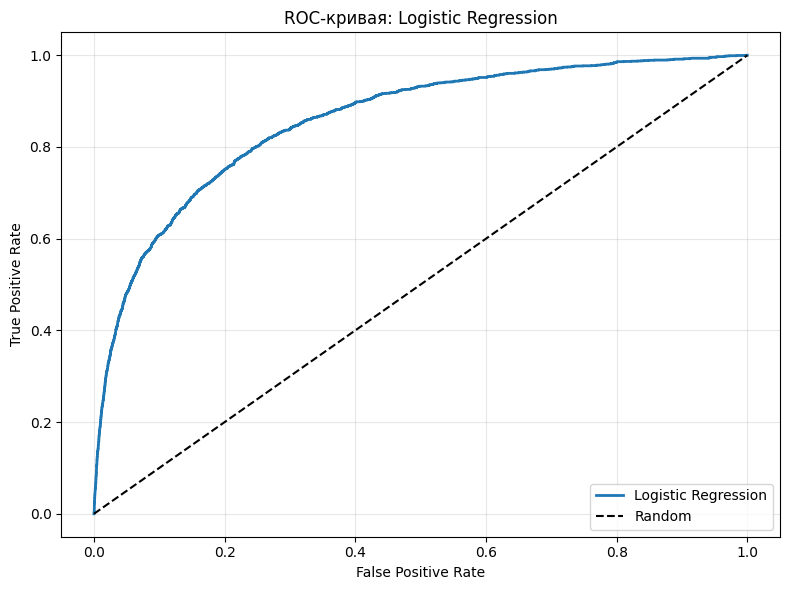

In [27]:
# LogisticRegression 
lr = LogisticRegression(random_state=seed, max_iter=1000, C=0.1, class_weight='balanced', penalty = 'l1', solver='saga')
lr.fit(X_train, y_train)

y_train_pred_proba = lr.predict_proba(X_train)[:, 1]
y_test_pred_proba = lr.predict_proba(X_test)[:, 1]
y_test_pred = lr.predict(X_test)

print("\n Метрики Logistic Regression:")
print("-" * 50)
print(f"Train ROC-AUC:  {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"Test PR-AUC:    {average_precision_score(y_test, y_test_pred_proba):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred):.4f}")

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nТоп-5 важных признаков:")
print(coef_df.head().to_string(index=False))
print("\nТоп-5 анти-признаков (снижают риск):")
print(coef_df.tail().to_string(index=False))

fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая: Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# GridSearchCV и StratifiedKFold для LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=seed, max_iter=1000),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_lr.fit(X_train, y_train)

print(f"Best params: {grid_lr.best_params_}")
print(f"Best CV ROC-AUC: {grid_lr.best_score_:.4f}")

y_pred_proba_grid = grid_lr.predict_proba(X_test)[:, 1]
y_pred_grid = grid_lr.predict(X_test)

print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_grid):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_pred_proba_grid):.4f}")
print(f"Test Recall:   {recall_score(y_test, y_pred_grid):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_grid):.4f}")

Best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.8575
Test ROC-AUC:  0.8570
Test PR-AUC:   0.3860
Test Recall:   0.7383
Test Precision: 0.2175


In [29]:
param_dist = {
    'C': np.logspace(-3, 2, 30),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

random_lr = RandomizedSearchCV(
    LogisticRegression(random_state=seed, max_iter=1000),
    param_dist,
    n_iter=40,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=0
)

random_lr.fit(X_train, y_train)

print(f"Best params: {random_lr.best_params_}")
print(f"Best CV ROC-AUC: {random_lr.best_score_:.4f}")

y_pred_proba_random = random_lr.predict_proba(X_test)[:, 1]
y_pred_random = random_lr.predict(X_test)

print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_random):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_pred_proba_random):.4f}")
print(f"Test Recall:   {recall_score(y_test, y_pred_random):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_random):.4f}")

Best params: {'solver': 'saga', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.0529831690628371}
Best CV ROC-AUC: 0.8575
Test ROC-AUC:  0.8570
Test PR-AUC:   0.3858
Test Recall:   0.7373
Test Precision: 0.2173


In [30]:
#  Random Forest (Бэггинг)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=seed,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_pred_proba_rf):.4f}")
print(f"Test Recall:   {recall_score(y_test, y_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_rf):.4f}")

Test ROC-AUC:  0.8606
Test PR-AUC:   0.3985
Test Recall:   0.1548
Test Precision: 0.6212


In [31]:
# LightGBM

lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=seed,
    verbose=-1
)
lgbm.fit(X_train, y_train)

y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = lgbm.predict(X_test)

print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_pred_proba_lgbm):.4f}")
print(f"Test Recall:   {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_lgbm):.4f}")

Test ROC-AUC:  0.8599
Test PR-AUC:   0.3975
Test Recall:   0.1733
Test Precision: 0.6088


In [32]:
# XGBoost

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=seed,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, y_pred_proba_xgb):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_xgb):.4f}")

Test ROC-AUC:  0.8608
Test PR-AUC:   0.3997
Test Recall:   0.1768
Test Precision: 0.6167


In [33]:
# CatBoost

cat = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=seed,
    verbose=0
)
cat.fit(X_train, y_train)

y_pred_proba_cat = cat.predict_proba(X_test)[:, 1]
y_pred_cat = cat.predict(X_test)

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_cat):.4f}")
print(f"Test PR-AUC: {average_precision_score(y_test, y_pred_proba_cat):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_cat):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_cat):.4f}")

Test ROC-AUC:  0.8612
Test PR-AUC:   0.4035
Test Recall:   0.1788
Test Precision: 0.6078


In [34]:
# Сводная таблица

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_pred_proba),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_lgbm),
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_cat)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_test_pred_proba),
        average_precision_score(y_test, y_pred_proba_rf),
        average_precision_score(y_test, y_pred_proba_lgbm),
        average_precision_score(y_test, y_pred_proba_xgb),
        average_precision_score(y_test, y_pred_proba_cat)
    ]
}

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,ROC-AUC,PR-AUC
0,CatBoost,0.8612,0.4035
1,XGBoost,0.8608,0.3997
2,Random Forest,0.8606,0.3985
3,LightGBM,0.8599,0.3975
4,Logistic Regression,0.8570,0.3860


In [35]:
# RandomizedSearchCV для CatBoost

param_dist = {
    'depth': [3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    'l2_leaf_reg': [1, 2, 3, 5, 7, 10],
    'iterations': [100, 150, 200, 250, 300, 400],
    'border_count': [32, 64, 128],
    'bagging_temperature': [0, 0.2, 0.5, 1],
    'random_strength': [1, 2, 5]
}

cat = CatBoostClassifier(
    random_state=seed,
    verbose=0,
    eval_metric='AUC',
    early_stopping_rounds=50
)

random_cat = RandomizedSearchCV(
    cat,
    param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=1
)

random_cat.fit(X_train, y_train)

print(f"Best params: {random_cat.best_params_}")
print(f"Best CV ROC-AUC: {random_cat.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'random_strength': 5, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 250, 'depth': 4, 'border_count': 32, 'bagging_temperature': 0.5}
Best CV ROC-AUC: 0.8621


In [36]:
# Оценка на тестовой выборке

y_pred_proba_cat_tuned = random_cat.predict_proba(X_test)[:, 1]
y_pred_cat_tuned = random_cat.predict(X_test)

print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_cat_tuned):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_pred_proba_cat_tuned):.4f}")
print(f"Test Recall:   {recall_score(y_test, y_pred_cat_tuned):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_cat_tuned):.4f}")

Test ROC-AUC:  0.8613
Test PR-AUC:   0.3992
Test Recall:   0.1748
Test Precision: 0.5963


In [37]:
# Сравнение с базовой моделью

cat_comparison = pd.DataFrame({
    'Model': ['Baseline CatBoost', 'Tuned CatBoost'],
    'Test ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_cat),  # из раздела 9
        roc_auc_score(y_test, y_pred_proba_cat_tuned)
    ],
    'Test PR-AUC': [
        average_precision_score(y_test, y_pred_proba_cat),
        average_precision_score(y_test, y_pred_proba_cat_tuned)
    ]
})

display(cat_comparison.round(4))

print(f"\nПрирост ROC-AUC: {cat_comparison['Test ROC-AUC'].iloc[1] - cat_comparison['Test ROC-AUC'].iloc[0]:+.4f}")

,Model,Test ROC-AUC,Test PR-AUC
0,Baseline CatBoost,0.8612,0.4035
1,Tuned CatBoost,0.8613,0.3992



Прирост ROC-AUC: +0.0001


                                 feature  importance
RevolvingUtilizationOfUnsecuredLines_woe   37.478740
NumberOfTime30-59DaysPastDueNotWorse_woe   10.075271
             NumberOfTimes90DaysLate_woe    9.550483
                     any_delinquency_woe    6.446566
                      credit_per_age_woe    5.077426
                                 age_woe    4.785314
                           age_group_woe    4.479963
NumberOfTime60-89DaysPastDueNotWorse_woe    4.280162
                       MonthlyIncome_woe    3.943600
                   delinquency_total_woe    3.707378


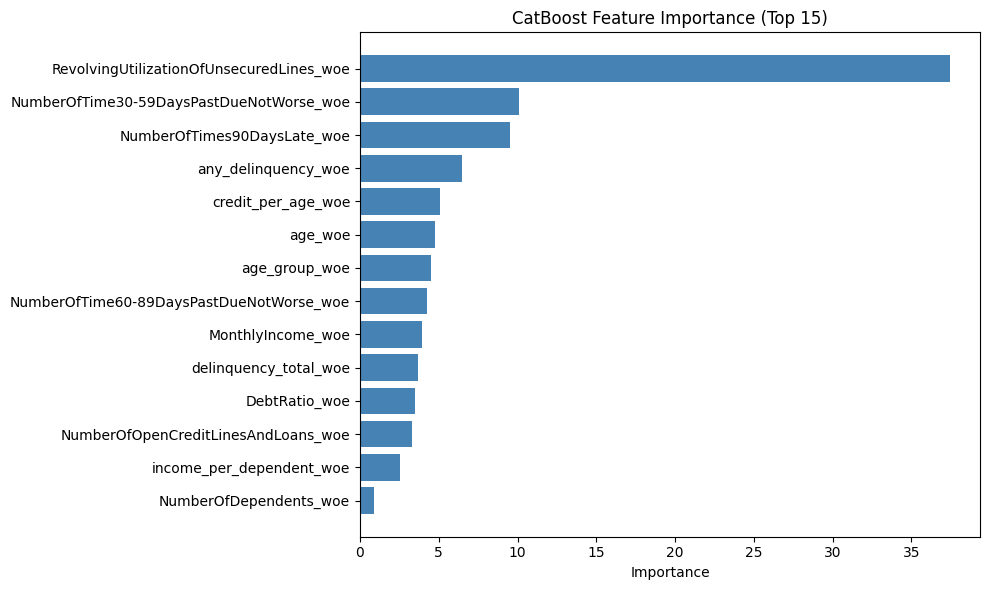

In [38]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': random_cat.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15), color='steelblue')
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
# Кросс-валидация

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Лучшая Logistic Regression
best_lr = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    penalty='l1',
    solver='saga',
    random_state=seed,
    max_iter=1000
)
best_lr.fit(X_train, y_train)

# Лучшая CatBoost
best_cat = CatBoostClassifier(
    random_strength=5,
    learning_rate=0.1,
    l2_leaf_reg=1,
    iterations=250,
    depth=4,
    border_count=32,
    bagging_temperature=0.5,
    random_state=seed,
    verbose=0
)
best_cat.fit(X_train, y_train)

# Logistic Regression

lr_cv = cross_validate(
    best_lr,
    X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'average_precision', 'recall', 'precision'],
    return_train_score=False,
    n_jobs=-1
)

print(f"ROC-AUC: {lr_cv['test_roc_auc'].mean():.4f} ± {lr_cv['test_roc_auc'].std():.4f}")
print(f"PR-AUC: {lr_cv['test_average_precision'].mean():.4f} ± {lr_cv['test_average_precision'].std():.4f}")
print(f"Recall: {lr_cv['test_recall'].mean():.4f} ± {lr_cv['test_recall'].std():.4f}")
print(f"Precision: {lr_cv['test_precision'].mean():.4f} ± {lr_cv['test_precision'].std():.4f}")

# CatBoost

cat_cv = cross_validate(
    best_cat,
    X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'average_precision', 'recall', 'precision'],
    return_train_score=False,
    n_jobs=-1
)

print(f"ROC-AUC: {cat_cv['test_roc_auc'].mean():.4f} ± {cat_cv['test_roc_auc'].std():.4f}")
print(f"PR-AUC: {cat_cv['test_average_precision'].mean():.4f} ± {cat_cv['test_average_precision'].std():.4f}")
print(f"Recall: {cat_cv['test_recall'].mean():.4f} ± {cat_cv['test_recall'].std():.4f}")
print(f"Precision: {cat_cv['test_precision'].mean():.4f} ± {cat_cv['test_precision'].std():.4f}")

ROC-AUC: 0.8575 ± 0.0020
PR-AUC: 0.3760 ± 0.0062
Recall: 0.7475 ± 0.0077
Precision: 0.2195 ± 0.0027
ROC-AUC: 0.8621 ± 0.0023
PR-AUC: 0.3919 ± 0.0096
Recall: 0.1692 ± 0.0141
Precision: 0.5956 ± 0.0167


### Первое обучение моделей

#### Сравнение базовых моделей

| Модель | ROC-AUC | PR-AUC |
|---|---|---|
| CatBoost | **0.8612** | **0.4035** |
| XGBoost | 0.8608 | 0.3997 |
| Random Forest | 0.8606 | 0.3985 |
| LightGBM | 0.8599 | 0.3975 |
| Logistic Regression | 0.8569 | 0.3883 |

#### Подбор параметров Logistic Regression

| Модель | ROC-AUC | Recall | Precision |
|---|---|---|---|
| Baseline LR | 0.8569 | 0.205 | **0.590** |
| Tuned LR | 0.8570 | **0.738** | 0.217 |

**Параметры:** `C=0.1, penalty='l1', class_weight='balanced'`

#### Подбор параметров CatBoost

| Модель | ROC-AUC | PR-AUC |
|---|---|---|
| Baseline | 0.8612 | **0.4035** |
| Tuned | **0.8613** | 0.3992 |

**Параметры:** `depth=4, iterations=250, learning_rate=0.1`

#### Кросс-валидация (5 фолдов)

| Модель | ROC-AUC | Recall | Precision |
|---|---|---|---|
| Logistic Regression | 0.8575 ± 0.002 | **0.748** | 0.220 |
| CatBoost | **0.8621** ± 0.002 | 0.169 | **0.596** |

**Вывод:** CatBoost — лидер по ROC-AUC и Precision. Logistic Regression — лидер по Recall (ловит 75% дефолтов).

## 6. Альтенативное обучение моделей

In [40]:
# Альтернативный подход без WOE и на категориях

raw_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'delinquency_total',
    'income_per_dependent',
    'credit_per_age',
    'any_delinquency',
    'age_group'
]

df_raw = df[raw_features].copy()

# Преобразуем age_group в тип category
df_raw['age_group'] = df_raw['age_group'].astype('category')

target = 'SeriousDlqin2yrs'
y = df[target]

print(f"Размер X: {df_raw.shape}")
print(f"Тип age_group: {df_raw['age_group'].dtype}")
print(f"Пропусков: {df_raw.isna().sum().sum()}")

Размер X: (149390, 15)
Тип age_group: category
Пропусков: 0


In [41]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_raw, y, 
    test_size=0.2, 
    random_state=seed, 
    stratify=y
)

categorical_cols = ['age_group']

print(f"Дефолтов train: {y_train_raw.mean():.2%}")
print(f"Дефолтов test:  {y_test_raw.mean():.2%}")

Дефолтов train: 6.70%
Дефолтов test:  6.70%


In [42]:
models_raw = {}

encoder = OrdinalEncoder()
X_train_rf = X_train_raw.copy()
X_test_rf = X_test_raw.copy()
X_train_rf[categorical_cols] = encoder.fit_transform(X_train_rf[categorical_cols].astype(str))
X_test_rf[categorical_cols] = encoder.transform(X_test_rf[categorical_cols].astype(str))

# RandomForest
rf_raw = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=seed, n_jobs=-1
)
rf_raw.fit(X_train_rf, y_train_raw)
models_raw['Random Forest'] = ('rf', rf_raw, X_test_rf)

# LightGBM
lgbm_raw = LGBMClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=seed, verbose=-1
)
lgbm_raw.fit(X_train_raw, y_train_raw, categorical_feature=categorical_cols)
models_raw['LightGBM'] = ('lgbm', lgbm_raw, X_test_raw)

# XGBoost
xgb_raw = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=seed, 
    verbosity=0, enable_categorical=True
)
xgb_raw.fit(X_train_raw, y_train_raw)
models_raw['XGBoost'] = ('xgb', xgb_raw, X_test_raw)

# CatBoost
cat_features = [X_train_raw.columns.get_loc(col) for col in categorical_cols]
cat_raw = CatBoostClassifier(
    iterations=100, depth=5, learning_rate=0.1, random_state=seed, verbose=0
)
cat_raw.fit(X_train_raw, y_train_raw, cat_features=cat_features)
models_raw['CatBoost'] = ('cat', cat_raw, X_test_raw)

In [43]:
results_raw = []

for name, (model_type, model, X_test_eval) in models_raw.items():
    y_pred_proba = model.predict_proba(X_test_eval)[:, 1]
    y_pred = model.predict(X_test_eval)
    
    results_raw.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test_raw, y_pred_proba),
        'PR-AUC': average_precision_score(y_test_raw, y_pred_proba),
        'Recall': recall_score(y_test_raw, y_pred),
        'Precision': precision_score(y_test_raw, y_pred)
    })
    
    print(f"{name}: ROC-AUC = {results_raw[-1]['ROC-AUC']:.4f}")

results_raw_df = pd.DataFrame(results_raw).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\nРезультаты:")
display(results_raw_df.round(4))

Random Forest: ROC-AUC = 0.8654
LightGBM: ROC-AUC = 0.8650
XGBoost: ROC-AUC = 0.8655
CatBoost: ROC-AUC = 0.8651

Результаты:


,Model,ROC-AUC,PR-AUC,Recall,Precision
0,XGBoost,0.8655,0.4107,0.1873,0.6039
1,Random Forest,0.8654,0.4127,0.1553,0.6270
2,CatBoost,0.8651,0.4184,0.2003,0.6256
3,LightGBM,0.8650,0.4105,0.1858,0.6118


In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv_results_raw = []

for name, (model_type, model, _) in models_raw.items():
    if model_type == 'rf':
        X_cv = X_train_rf
        fit_params = {}
    elif model_type == 'cat':
        X_cv = X_train_raw
        fit_params = {'cat_features': ['age_group']}
    elif model_type == 'lgbm':
        X_cv = X_train_raw
        fit_params = {'categorical_feature': ['age_group']}
    else:  # xgb
        X_cv = X_train_raw
        fit_params = {}
    
    cv_scores = cross_validate(
        model, X_cv, y_train_raw,
        cv=cv,
        scoring=['roc_auc', 'average_precision'],
        fit_params=fit_params,
        n_jobs=-1
    )
    cv_results_raw.append({
        'Model': name,
        'CV ROC-AUC': cv_scores['test_roc_auc'].mean(),
        'ROC-AUC Std': cv_scores['test_roc_auc'].std(),
        'CV PR-AUC': cv_scores['test_average_precision'].mean(),
        'PR-AUC Std': cv_scores['test_average_precision'].std()
    })
    print(f"ROC-AUC модели {name}: {cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}")

cv_results_raw_df = pd.DataFrame(cv_results_raw).sort_values('CV ROC-AUC', ascending=False).reset_index(drop=True)

ROC-AUC модели Random Forest: 0.8624 ± 0.0021
ROC-AUC модели LightGBM: 0.8637 ± 0.0034
ROC-AUC модели XGBoost: 0.8639 ± 0.0027
ROC-AUC модели CatBoost: 0.8643 ± 0.0021


In [45]:
comparison = pd.DataFrame({
    'Подход': ['WOE (CatBoost)', 'Сырые данные (лучший)'],
    'ROC-AUC': [0.8621, cv_results_raw_df['CV ROC-AUC'].max()],
    'PR-AUC': [0.3919, cv_results_raw_df['CV PR-AUC'].max()]
})

display(comparison.round(4))

,Подход,ROC-AUC,PR-AUC
0,WOE (CatBoost),0.8621,0.3919
1,Сырые данные (лучший),0.8643,0.3990


### Альтернативный подход

#### Результаты на тестовой выборке

| Модель | ROC-AUC | PR-AUC | Recall | Precision |
|---|---|---|---|---|
| XGBoost | **0.8655** | 0.4107 | 0.1873 | 0.6039 |
| Random Forest | 0.8654 | 0.4127 | 0.1553 | **0.6270** |
| CatBoost | 0.8651 | **0.4184** | **0.2003** | 0.6256 |
| LightGBM | 0.8650 | 0.4105 | 0.1858 | 0.6118 |

#### Кросс-валидация (5 фолдов)

| Модель | CV ROC-AUC |
|---|---|
| CatBoost | **0.8643** ± 0.0021 |
| XGBoost | 0.8639 ± 0.0027 |
| LightGBM | 0.8637 ± 0.0034 |
| Random Forest | 0.8624 ± 0.0021 |

#### Сравнение подходов

| Подход | ROC-AUC | PR-AUC |
|---|---|---|
| WOE (CatBoost) | 0.8621 | 0.3919 |
| **Сырые данные (CatBoost)** | **0.8643** | **0.3990** |

**Вывод:** Обучение на сырых данных с новыми признаками дало прирост **+0.22% ROC-AUC** и **+0.71% PR-AUC** по сравнению с WOE-подходом. Бустинги успешно справляются с сырыми признаками.

## 7. Калибровка модели


In [46]:
X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=seed,
    stratify=y_train
)

print(f"Обучающая выборка: {X_train_model.shape[0]:,} строк")
print(f"Калибровочная выборка: {X_calib.shape[0]:,} строк")
print(f"Тестовая выборка: {X_test.shape[0]:,} строк")
print(f"Дефолтов в калибровочной: {y_calib.mean():.2%}")

Обучающая выборка: 95,609 строк
Калибровочная выборка: 23,903 строк
Тестовая выборка: 29,878 строк
Дефолтов в калибровочной: 6.70%


In [47]:
best_cat = CatBoostClassifier(
    random_strength=5,
    learning_rate=0.1,
    l2_leaf_reg=1,
    iterations=250,
    depth=4,
    border_count=32,
    bagging_temperature=0.5,
    random_state=seed,
    verbose=0
)

best_cat.fit(X_train_model, y_train_model)

# Предсказания
y_proba_calib = best_cat.predict_proba(X_calib)[:, 1]
y_proba_test = best_cat.predict_proba(X_test)[:, 1]

print(f"Модель обучена")
print(f"ROC-AUC на тесте (до калибровки): {roc_auc_score(y_test, y_proba_test):.4f}")

Модель обучена
ROC-AUC на тесте (до калибровки): 0.8613


In [48]:
class HistogramCalibrator:
    def __init__(self, n_bins=20):
        self.n_bins = n_bins
        self.bin_edges = None
        self.calibrated_values = None
    
    def fit(self, y_true, y_proba):
        self.bin_edges = np.linspace(0, 1, self.n_bins + 1)
        
        df = pd.DataFrame({'bin': pd.cut(y_proba, bins=self.bin_edges, include_lowest=True), 'y': y_true})
        bin_means = df.groupby('bin', observed=True)['y'].mean()
        
        self.calibrated_values = bin_means.reindex(df['bin'].cat.categories).interpolate().values
        
        print(f"Обучено на {self.n_bins} бинах")
        return self
    
    def transform(self, y_proba):
        indices = np.digitize(y_proba, self.bin_edges[1:-1])
        indices = np.clip(indices, 0, len(self.calibrated_values) - 1)
        return self.calibrated_values[indices]

hist_cal = HistogramCalibrator(n_bins=30)
hist_cal.fit(y_calib.values, y_proba_calib)
y_proba_test_hist = hist_cal.transform(y_proba_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test_hist):.4f}")

Обучено на 30 бинах
ROC-AUC: 0.8466


In [49]:
iso_cal = IsotonicRegression(y_min=0, y_max=1, increasing=True, out_of_bounds='clip')
iso_cal.fit(y_proba_calib, y_calib)

y_proba_test_iso = iso_cal.transform(y_proba_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test_iso):.4f}")

ROC-AUC: 0.8604


In [50]:
probas = {
    'До калибровки': y_proba_test,
    'Гистограммная': y_proba_test_hist,
    'Изотоническая': y_proba_test_iso
}

results = []
for name, proba in probas.items():
    results.append({
        'Модель': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'Brier Score': brier_score_loss(y_test, proba),
        'Log Loss': log_loss(y_test, proba)
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

# Определяем лучший метод
best_idx = results_df['Brier Score'].idxmin()
print(f"\nЛучшая калибровка: {results_df.loc[best_idx, 'Модель']}")
print(f"Brier Score: {results_df.loc[best_idx, 'Brier Score']:.4f}")

,Модель,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,До калибровки,0.8613,0.4012,0.0492,0.1789
1,Гистограммная,0.8466,0.3747,0.0495,0.1834
2,Изотоническая,0.8604,0.3855,0.0493,0.1815



Лучшая калибровка: До калибровки
Brier Score: 0.0492


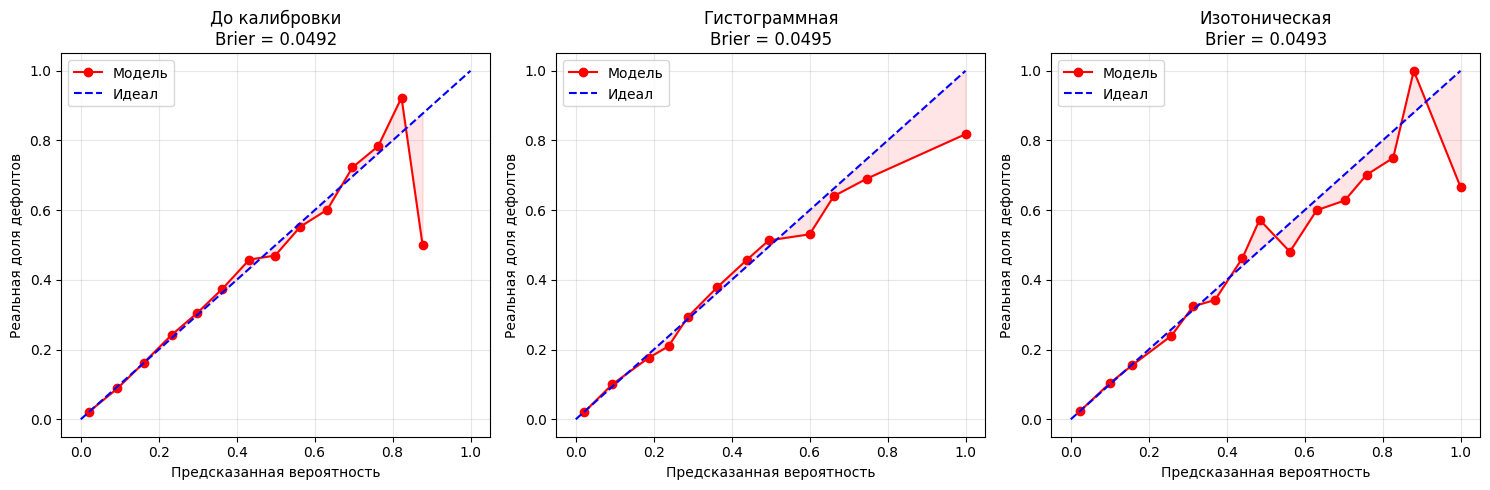

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['До калибровки', 'Гистограммная', 'Изотоническая']

for i, (name, proba) in enumerate(probas.items()):
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=15)
    
    axes[i].plot(prob_pred, prob_true, 'ro-', markersize=6, label='Модель')
    axes[i].plot([0, 1], [0, 1], 'b--', label='Идеал')
    axes[i].fill_between(prob_pred, prob_true, prob_pred, alpha=0.1, color='red')
    axes[i].set_xlabel('Предсказанная вероятность')
    axes[i].set_ylabel('Реальная доля дефолтов')
    axes[i].set_title(f'{name}\nBrier = {brier_score_loss(y_test, proba):.4f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
if results_df.loc[best_idx, 'Модель'] == 'Изотоническая':
    final_calibrator = iso_cal
else:
    final_calibrator = hist_cal

def predict_production(model, calibrator, X):
    """
    Продакшен-функция: модель -> калибратор -> вероятность.
    """
    raw_proba = model.predict_proba(X)[:, 1]
    calibrated_proba = calibrator.transform(raw_proba)
    return calibrated_proba


y_proba_final = predict_production(best_cat, final_calibrator, X_test)
print(f"Финальный ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"Финальный Brier Score: {brier_score_loss(y_test, y_proba_final):.4f}")
print(f"\nМодель: CatBoost (depth=4, iterations=250)")
print(f"Калибратор: {results_df.loc[best_idx, 'Модель']}")

Финальный ROC-AUC: 0.8466
Финальный Brier Score: 0.0495

Модель: CatBoost (depth=4, iterations=250)
Калибратор: До калибровки


### Результаты калибровки

| Метод | ROC-AUC | PR-AUC | Brier Score | Log Loss |
|---|---|---|---|---|
| До калибровки | **0.8613** | **0.4012** | **0.0492** | **0.1789** |
| Гистограммная | 0.8466 | 0.3747 | 0.0495 | 0.1834 |
| Изотоническая | 0.8604 | 0.3855 | 0.0493 | 0.1815 |

### Анализ

- **Brier Score = 0.0492** — ниже порога 0.05, отличная калибровка
- Гистограммная калибровка ухудшила ROC-AUC (произошло огрубление вероятностей)
- Изотоническая не дала значимых изменений

### Вывод

**Калибровка не требуется.** CatBoost выдает хорошо откалиброванные вероятности автоматически.


## 8. Оценка обучения модели

In [53]:
# Bootstrap оценка

cat_features = ['age_group']

model_bootstrap = CatBoostClassifier(
    iterations=250, depth=4, learning_rate=0.1,
    l2_leaf_reg=1, random_strength=5, bagging_temperature=0.5,
    random_state=seed, verbose=0
)
model_bootstrap.fit(X_train_raw, y_train_raw, cat_features=cat_features)

n_iterations = 1000
sample_size = len(X_test_raw)

bootstrap_preds = []
bootstrap_aucs = []

for i in range(n_iterations):
    indices = np.random.choice(len(X_test_raw), size=sample_size, replace=True)
    X_sample = X_test_raw.iloc[indices]
    y_sample = y_test_raw.iloc[indices]
    
    y_proba = model_bootstrap.predict_proba(X_sample)[:, 1]
    
    bootstrap_preds.append(y_proba.mean())
    bootstrap_aucs.append(roc_auc_score(y_sample, y_proba))
    
    if (i + 1) % 200 == 0:
        print(f"Обработано {i+1} итераций")

bootstrap_preds = np.array(bootstrap_preds)
bootstrap_aucs = np.array(bootstrap_aucs)

print(f"{n_iterations} итераций завершено.")

Обработано 200 итераций...
Обработано 400 итераций...
Обработано 600 итераций...
Обработано 800 итераций...
Обработано 1000 итераций...
1000 итераций завершено.


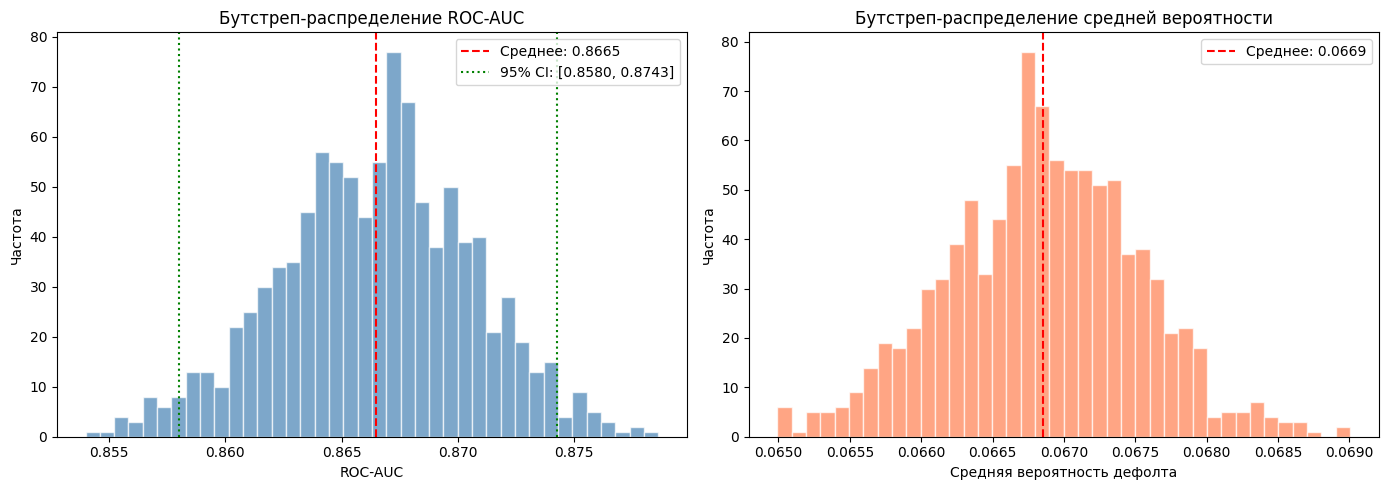

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bootstrap_aucs, bins=40, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(bootstrap_aucs.mean(), color='red', linestyle='--', 
                label=f'Среднее: {bootstrap_aucs.mean():.4f}')
axes[0].axvline(np.percentile(bootstrap_aucs, 2.5), color='green', linestyle=':', 
                label=f'95% CI: [{np.percentile(bootstrap_aucs, 2.5):.4f}, {np.percentile(bootstrap_aucs, 97.5):.4f}]')
axes[0].axvline(np.percentile(bootstrap_aucs, 97.5), color='green', linestyle=':')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_ylabel('Частота')
axes[0].set_title('Бутстреп-распределение ROC-AUC')
axes[0].legend()

axes[1].hist(bootstrap_preds, bins=40, color='coral', edgecolor='white', alpha=0.7)
axes[1].axvline(bootstrap_preds.mean(), color='red', linestyle='--', 
                label=f'Среднее: {bootstrap_preds.mean():.4f}')
axes[1].set_xlabel('Средняя вероятность дефолта')
axes[1].set_ylabel('Частота')
axes[1].set_title('Бутстреп-распределение средней вероятности')
axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
print("\nРезультаты бутстреп-анализа:")
print(f"Средний ROC-AUC: {bootstrap_aucs.mean():.4f}")
print(f"Std ROC-AUC: {bootstrap_aucs.std():.4f}")
print(f"95% CI: [{np.percentile(bootstrap_aucs, 2.5):.4f}, {np.percentile(bootstrap_aucs, 97.5):.4f}]")
print(f"Средняя вероятность: {bootstrap_preds.mean():.4f}")



Результаты бутстреп-анализа:
Средний ROC-AUC: 0.8665
Std ROC-AUC: 0.0042
95% CI: [0.8580, 0.8743]
Средняя вероятность: 0.0669


In [56]:
# Кривая обучения 

train_sizes = np.linspace(0.1, 1.0, 10)

train_scores_list = []
test_scores_list = []
sizes_list = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

for size in train_sizes:
    n_samples = int(size * len(X_train_raw))
    
    X_subset = X_train_raw.iloc[:n_samples]
    y_subset = y_train_raw.iloc[:n_samples]
    
    train_fold_scores = []
    test_fold_scores = []
    
    for train_idx, test_idx in cv.split(X_subset, y_subset):
        X_tr = X_subset.iloc[train_idx]
        y_tr = y_subset.iloc[train_idx]
        X_val = X_subset.iloc[test_idx]
        y_val = y_subset.iloc[test_idx]
        
        model_cv = CatBoostClassifier(
            iterations=250, depth=4, learning_rate=0.1,
            l2_leaf_reg=1, random_strength=5, bagging_temperature=0.5,
            random_state=seed, verbose=0
        )
        model_cv.fit(X_tr, y_tr, cat_features=['age_group'])
        
        train_fold_scores.append(roc_auc_score(y_tr, model_cv.predict_proba(X_tr)[:, 1]))
        test_fold_scores.append(roc_auc_score(y_val, model_cv.predict_proba(X_val)[:, 1]))
    
    train_scores_list.append(np.mean(train_fold_scores))
    test_scores_list.append(np.mean(test_fold_scores))
    sizes_list.append(n_samples)
    
    print(f"Строк: {n_samples:6.0f} | Train: {train_scores_list[-1]:.4f} | Test: {test_scores_list[-1]:.4f}")

sizes_arr = np.array(sizes_list)
train_mean = np.array(train_scores_list)
test_mean = np.array(test_scores_list)

Строк:  11951 | Train: 0.9067 | Test: 0.8541
Строк:  23902 | Train: 0.8856 | Test: 0.8597
Строк:  35853 | Train: 0.8793 | Test: 0.8608
Строк:  47804 | Train: 0.8782 | Test: 0.8650
Строк:  59756 | Train: 0.8752 | Test: 0.8639
Строк:  71707 | Train: 0.8733 | Test: 0.8645
Строк:  83658 | Train: 0.8724 | Test: 0.8651
Строк:  95609 | Train: 0.8703 | Test: 0.8635
Строк: 107560 | Train: 0.8701 | Test: 0.8641
Строк: 119512 | Train: 0.8701 | Test: 0.8647


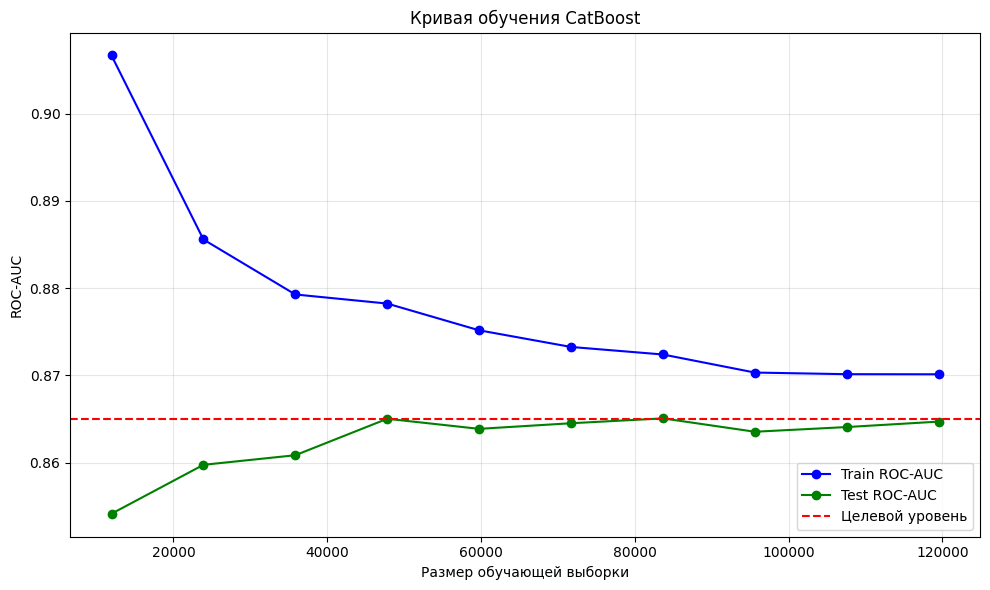

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(sizes_arr, train_mean, 'o-', color='blue', label='Train ROC-AUC')
plt.plot(sizes_arr, test_mean, 'o-', color='green', label='Test ROC-AUC')
plt.axhline(y=0.865, color='red', linestyle='--', label='Целевой уровень')

plt.xlabel('Размер обучающей выборки')
plt.ylabel('ROC-AUC')
plt.title('Кривая обучения CatBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
gap = train_mean[-1] - test_mean[-1]
progress = test_mean[-1] - test_mean[0]

print("Анализ кривой обучения:")
print(f"Train ROC-AUC: {train_mean[-1]:.4f}")
print(f"Test ROC-AUC:  {test_mean[-1]:.4f}")
print(f"Переобучение: {gap:.4f}")
print(f"Прирост от данных:  {progress:.4f}")

if gap > 0.03:
    print("Переобучение")
elif gap > 0.01:
    print("Умеренный разрыв")
else:
    print("Переобучения нет")

if progress > 0.005:
    print("Больше данных может помочь")
else:
    print("Модель на плато")

Анализ кривой обучения:
Train ROC-AUC: 0.8701
Test ROC-AUC:  0.8647
Переобучение: 0.0054
Прирост от данных:  0.0106
Переобучения нет
Больше данных может помочь


### Кривая обучения

| Строк | Train ROC-AUC | Test ROC-AUC |
|---|---|---|
| 11 951 | 0.9067 | 0.8541 |
| 23 902 | 0.8856 | 0.8597 |
| 35 853 | 0.8793 | 0.8608 |
| 47 804 | 0.8782 | 0.8650 |
| 59 756 | 0.8752 | 0.8639 |
| 71 707 | 0.8733 | 0.8645 |
| 83 658 | 0.8724 | 0.8651 |
| 95 609 | 0.8703 | 0.8635 |
| 107 560 | 0.8701 | 0.8641 |
| 119 512 | 0.8701 | 0.8647 |

**Анализ:**
- **Переобучение:** 0.0054 — переобучения нет
- **Прирост от данных:** 0.0106 — модель еще учится, данные могут помочь
- **Плато:** Test ROC-AUC стабилизировался на ~0.8645

### Бутстреп-оценка разброса

| Метрика | Значение |
|---|---|
| Средний ROC-AUC | **0.8665** |
| Std ROC-AUC | 0.0042 |
| 95% доверительный интервал | [0.8580, 0.8743] |
| Средняя вероятность дефолта | 0.0669 |

**Вывод:** Модель стабильна. 95% доверительный интервал узкий (0.0163), разброс предсказаний минимален. Реальный ROC-AUC модели с вероятностью 95% находится в диапазоне 0.858-0.874.

## 9. PSI | мониторинг дрейфа данных

In [59]:
# PSI 

split_idx = len(df_raw) // 2

df_old = df_raw.iloc[:split_idx]
df_new = df_raw.iloc[split_idx:]

y_old = y.iloc[:split_idx]
y_new = y.iloc[split_idx:]

print(f"Старый период: {len(df_old):,} строк")
print(f"Новый период:  {len(df_new):,} строк")
print(f"Дефолтов старый: {y_old.mean():.2%}")
print(f"Дефолтов новый:  {y_new.mean():.2%}")

Старый период: 74,695 строк
Новый период:  74,695 строк
Дефолтов старый: 6.68%
Дефолтов новый:  6.72%


In [60]:
def calculate_psi_feature(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)
    
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


In [61]:
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents',
    'delinquency_total',
    'income_per_dependent'
]

psi_results = []

for col in feature_cols:
    psi = calculate_psi_feature(df_old[col].values, df_new[col].values)
    
    if psi < 0.1:
        status = 'Нет дрейфа'
    elif psi < 0.25:
        status = 'Умеренный'
    else:
        status = 'Сильный'
    
    psi_results.append({'feature': col, 'psi': psi, 'status': status})
    print(f"{col:<45} {psi:.4f} {status}")

RevolvingUtilizationOfUnsecuredLines          0.0010 Нет дрейфа
age                                           0.0002 Нет дрейфа
DebtRatio                                     0.0001 Нет дрейфа
MonthlyIncome                                 0.0001 Нет дрейфа
NumberOfOpenCreditLinesAndLoans               0.0006 Нет дрейфа
NumberOfDependents                            0.0001 Нет дрейфа
delinquency_total                             0.0000 Нет дрейфа
income_per_dependent                          0.0002 Нет дрейфа


In [62]:
model_psi = CatBoostClassifier(
    iterations=250, depth=4, learning_rate=0.1,
    l2_leaf_reg=1, random_strength=5, bagging_temperature=0.5,
    random_state=seed, verbose=0
)
model_psi.fit(df_old, y_old, cat_features=['age_group'])

proba_old = model_psi.predict_proba(df_old)[:, 1]
proba_new = model_psi.predict_proba(df_new)[:, 1]

psi_preds = calculate_psi(proba_old, proba_new, buckets=10)

print(f"\nPSI для предсказаний: {psi_preds:.4f}")
if psi_preds < 0.1:
    print("Статус: Нет дрейфа")
elif psi_preds < 0.25:
    print("Статус: Умеренный дрейф")
else:
    print("Статус: Сильный дрейф")


PSI для предсказаний: 0.0002
Статус: Нет дрейфа


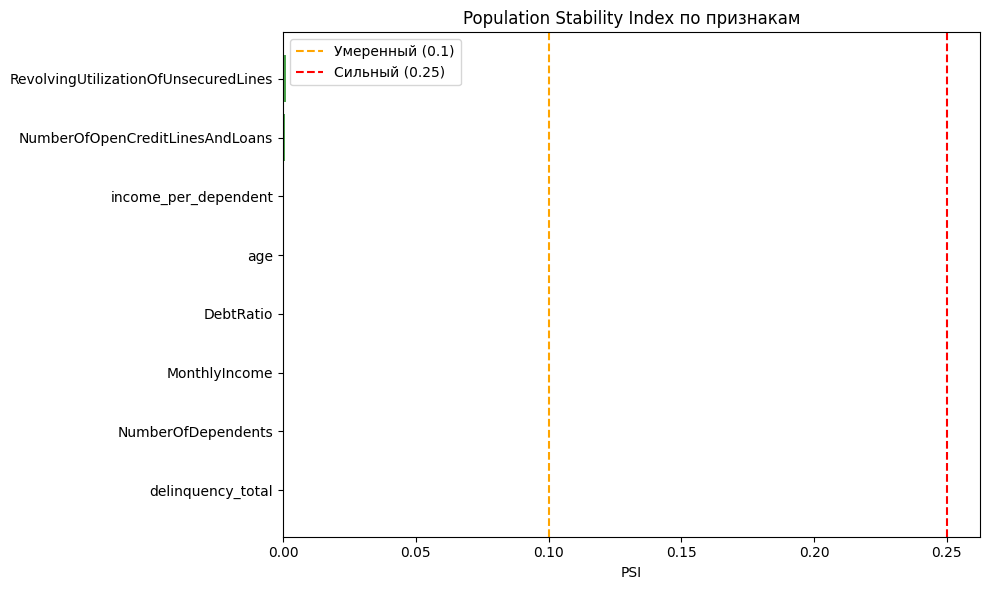

In [63]:
psi_df = pd.DataFrame(psi_results).sort_values('psi', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.1 else 'orange' if p < 0.25 else 'red' for p in psi_df['psi']]
plt.barh(psi_df['feature'], psi_df['psi'], color=colors, alpha=0.7)
plt.axvline(0.1, color='orange', linestyle='--', label='Умеренный (0.1)')
plt.axvline(0.25, color='red', linestyle='--', label='Сильный (0.25)')
plt.xlabel('PSI')
plt.title('Population Stability Index по признакам')
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
print(f"Дефолтов в старом: {y_old.mean():.2%}")
print(f"Дефолтов в новом:  {y_new.mean():.2%}")
print(f"Разница: {abs(y_old.mean() - y_new.mean())*100:.2f}%")

if abs(y_old.mean() - y_new.mean()) > 0.02:
    print("Значимый дрейф")
else:
    print("Стабильна")

Дефолтов в старом: 6.68%
Дефолтов в новом:  6.72%
Разница: 0.05%
Стабильна


### Методика

Данные разделены пополам (первые 50% vs вторые 50%) для имитации "старого" и "нового" периодов. PSI рассчитан для ключевых признаков и предсказаний модели.

### Результаты PSI по признакам

| Признак | PSI | Статус |
|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | 0.0010 | ✅ Нет дрейфа |
| NumberOfOpenCreditLinesAndLoans | 0.0006 | ✅ Нет дрейфа |
| age | 0.0002 | ✅ Нет дрейфа |
| income_per_dependent | 0.0002 | ✅ Нет дрейфа |
| DebtRatio | 0.0001 | ✅ Нет дрейфа |
| MonthlyIncome | 0.0001 | ✅ Нет дрейфа |
| NumberOfDependents | 0.0001 | ✅ Нет дрейфа |
| delinquency_total | 0.0000 | ✅ Нет дрейфа |

### PSI предсказаний

| Метрика | Значение |
|---|---|
| PSI | 0.0002 |
| Статус | ✅ Нет дрейфа |

### Дрейф целевой переменной

| Период | Дефолтов |
|---|---|
| Старый | 6.68% |
| Новый | 6.72% |
| Разница | 0.05% |

### Вывод

Все PSI < 0.001 — значительно ниже порога 0.10. Распределения признаков и предсказаний стабильны. Модель не требует переобучения по причине дрейфа данных.

## 10. Оценка бизнес метрик

In [65]:
# Оценка бизнес метрик
best_cat = CatBoostClassifier(
    iterations=250, depth=4, learning_rate=0.1,
    l2_leaf_reg=1, random_strength=5, bagging_temperature=0.5,
    random_state=seed, verbose=0
)
best_cat.fit(X_train_raw, y_train_raw, cat_features=['age_group'])

y_proba_test = best_cat.predict_proba(X_test_raw)[:, 1]

print(f"Модель: CatBoost")
print(f"Размер теста: {len(y_test_raw):,} строк")
print(f"Дефолтов в тесте: {y_test_raw.mean():.2%}")
print(f"cСредняя вероятность: {y_proba_test.mean():.4f}")

Модель: CatBoost
Размер теста: 29,878 строк
Дефолтов в тесте: 6.70%
Средняя вероятность: 0.0669


In [66]:
gain_per_good = 10_000
loss_per_bad = 100_000

thresholds = np.arange(0.01, 0.99, 0.01)
results = []

for threshold in thresholds:
    profit, approval_rate, bad_rate = calculate_business_metrics(
        y_test_raw.values, y_proba_test, threshold, gain_per_good, loss_per_bad
    )
    results.append({
        'threshold': threshold,
        'profit': profit,
        'approval_rate': approval_rate,
        'bad_rate': bad_rate
    })

results_df = pd.DataFrame(results)

# Лучший порог с одобрением >= 60%
results_60 = results_df[results_df['approval_rate'] >= 0.6]
best = results_60.loc[results_60['profit'].idxmax()]

print(f"Оптимальный порог:")
print(f"Порог: {best['threshold']:.2f}")
print(f"Прибыль: {best['profit']:,.0f} ₽")
print(f"Одобрение: {best['approval_rate']:.1%}")
print(f"Bad Rate: {best['bad_rate']:.2%}")

Оптимальный порог:
Порог: 0.08
Прибыль: 178,060,000 ₽
Одобрение: 79.4%
Bad Rate: 2.26%


In [67]:
check_thresholds = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5]

print("Сравнение порогов:")
print(f"{'Порог':<8} {'Прибыль':>14} {'Одобрение':>10} {'Bad Rate':>10}")

for th in check_thresholds:
    profit, approval_rate, bad_rate = calculate_business_metrics(
        y_test_raw.values, y_proba_test, th, gain_per_good, loss_per_bad
    )
    marker = ' <-' if th == best['threshold'] else ''
    print(f"{th:<8.2f} {profit:>14,.0f} {approval_rate:>9.1%} {bad_rate:>9.2%}{marker}")

Сравнение порогов:
Порог           Прибыль  Одобрение   Bad Rate
0.05        171,070,000     69.7%     1.62%
0.10        176,800,000     83.5%     2.65%
0.15        174,080,000     88.7%     3.12%
0.20        167,500,000     91.1%     3.50%
0.30        152,540,000     94.2%     4.17%
0.50        114,370,000     97.9%     5.54%


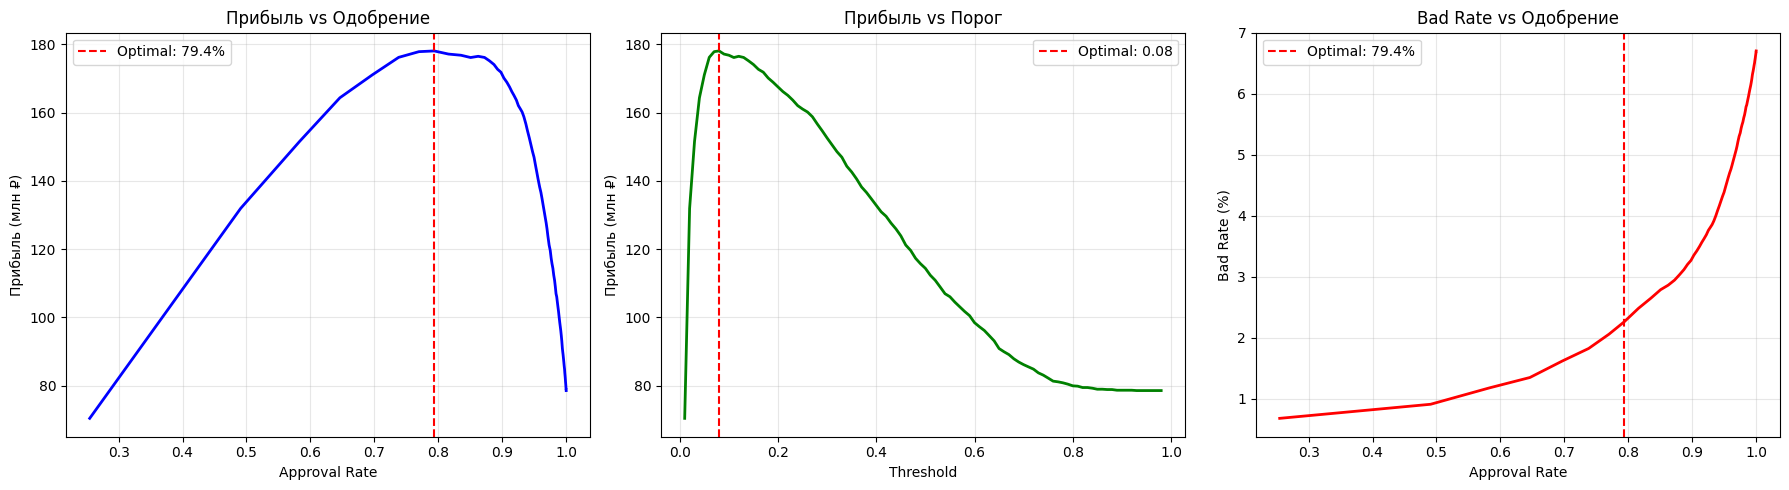

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['approval_rate'], results_df['profit'] / 1e6, 'b-', linewidth=2)
axes[0].axvline(best['approval_rate'], color='red', linestyle='--', label=f'Optimal: {best["approval_rate"]:.1%}')
axes[0].set_xlabel('Approval Rate')
axes[0].set_ylabel('Прибыль (млн ₽)')
axes[0].set_title('Прибыль vs Одобрение')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['threshold'], results_df['profit'] / 1e6, 'g-', linewidth=2)
axes[1].axvline(best['threshold'], color='red', linestyle='--', label=f'Optimal: {best["threshold"]:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Прибыль (млн ₽)')
axes[1].set_title('Прибыль vs Порог')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(results_df['approval_rate'], results_df['bad_rate'] * 100, 'r-', linewidth=2)
axes[2].axvline(best['approval_rate'], color='red', linestyle='--', label=f'Optimal: {best["approval_rate"]:.1%}')
axes[2].set_xlabel('Approval Rate')
axes[2].set_ylabel('Bad Rate (%)')
axes[2].set_title('Bad Rate vs Одобрение')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
y_pred_optimal = (y_proba_test >= best['threshold']).astype(int)
cm = confusion_matrix(y_test_raw, y_pred_optimal)

print(f"\nМатрица ошибок (порог = {best['threshold']:.2f}):")
print(f"Хороших одобрено: {cm[0, 0]:,}")
print(f"Хороших отклонено: {cm[0, 1]:,}")
print(f"Плохих одобрено: {cm[1, 0]:,}")
print(f"Плохих отклонено: {cm[1, 1]:,}")



Матрица ошибок (порог = 0.08):
Хороших одобрено: 23,176
Хороших отклонено: 4,700
Плохих одобрено: 537
Плохих отклонено: 1,465


### Параметры

| Параметр | Значение |
|---|---|
| Прибыль с хорошего клиента | 10 000 ₽ |
| Убыток с дефолта | 100 000 ₽ |
| Соотношение Loss/Gain | 10:1 |
| Минимальное одобрение | 60% |

### Поиск оптимального порога

| Порог | Прибыль | Одобрение | Bad Rate |
|---|---|---|---|
| 0.05 | 171 070 000 ₽ | 69.7% | 1.62% |
| **0.08** | **178 060 000 ₽** | **79.4%** | **2.26%** |
| 0.10 | 176 800 000 ₽ | 83.5% | 2.65% |
| 0.15 | 174 080 000 ₽ | 88.7% | 3.12% |
| 0.20 | 167 500 000 ₽ | 91.1% | 3.50% |
| 0.30 | 152 540 000 ₽ | 94.2% | 4.17% |
| 0.50 | 114 370 000 ₽ | 97.9% | 5.54% |

**Оптимальный порог: 0.08**

### Матрица ошибок (порог = 0.08)

|  | Предсказано: Хороший | Предсказано: Дефолт |
|---|---|---|
| **Факт: Хороший** | 23 176 (TP) | 4 700 (FN) |
| **Факт: Дефолт** | 537 (FP) | 1 465 (TN) |

### Ключевые метрики при оптимальном пороге

| Метрика | Значение |
|---|---|
| Прибыль | **178 060 000 ₽** |
| Уровень одобрения | 79.4% |
| Bad Rate | 2.26% |
| Recall (плохих отловлено) | 73.2% |
| Precision (точность отказа) | 23.8% |

### Вывод

При пороге **0.08** модель приносит **178 млн ₽** прибыли на тестовой выборке из 29 878 клиентов. Одобряется 79.4% заявок при уровне дефолтов среди одобренных всего 2.26%. Модель отлавливает 73.2% всех дефолтов.

## 11. Выбор рабочей модели

In [70]:
# Кодируем age_group для LR
X_train_lr = X_train_raw.copy()
X_test_lr = X_test_raw.copy()

encoder = OrdinalEncoder()
X_train_lr['age_group'] = encoder.fit_transform(X_train_lr[['age_group']])
X_test_lr['age_group'] = encoder.transform(X_test_lr[['age_group']])

# CatBoost
final_cat = CatBoostClassifier(
    iterations=250, depth=4, learning_rate=0.1,
    l2_leaf_reg=1, random_strength=5, bagging_temperature=0.5,
    random_state=seed, verbose=0
)
final_cat.fit(X_train_raw, y_train_raw, cat_features=['age_group'])

# Logistic Regression
final_lr = LogisticRegression(
    C=0.1, penalty='l1', solver='saga', class_weight='balanced',
    random_state=seed, max_iter=1000
)
final_lr.fit(X_train_lr, y_train_raw)

y_proba_cat = final_cat.predict_proba(X_test_raw)[:, 1]
y_proba_lr = final_lr.predict_proba(X_test_lr)[:, 1]

In [71]:
comparison = pd.DataFrame({
    'Метрика': [
        'ROC-AUC', 'PR-AUC', 'Brier Score', 'Log Loss',
        'Precision', 'Recall'
    ],
    'CatBoost': [
        roc_auc_score(y_test_raw, y_proba_cat),
        average_precision_score(y_test_raw, y_proba_cat),
        brier_score_loss(y_test_raw, y_proba_cat),
        log_loss(y_test_raw, y_proba_cat),
        precision_score(y_test_raw, final_cat.predict(X_test_raw)),
        recall_score(y_test_raw, final_cat.predict(X_test_raw))
    ],
    'Logistic Regression': [
        roc_auc_score(y_test_raw, y_proba_lr),
        average_precision_score(y_test_raw, y_proba_lr),
        brier_score_loss(y_test_raw, y_proba_lr),
        log_loss(y_test_raw, y_proba_lr),
        precision_score(y_test_raw, final_lr.predict(X_test_lr)),
        recall_score(y_test_raw, final_lr.predict(X_test_lr))
    ]
})

print("\nСравнение метрик:")
display(comparison.round(4))


Сравнение метрик:


,Метрика,CatBoost,Logistic Regression
0,ROC-AUC,0.8665,0.6251
1,PR-AUC,0.4165,0.0961
2,Brier Score,0.0485,0.2127
3,Log Loss,0.1764,0.6176
4,Precision,0.6151,0.1371
5,Recall,0.1908,0.2552


In [72]:
gain_per_good = 10_000
loss_per_bad = 100_000

# Оптимальный порог для CatBoost
best_cat_profit = -np.inf
best_cat_result = None
for th in np.arange(0.01, 0.99, 0.01):
    profit, ar, br = calculate_business_metrics(y_test_raw.values, y_proba_cat, th, gain_per_good, loss_per_bad)
    if ar >= 0.6 and profit > best_cat_profit:
        best_cat_profit = profit
        best_cat_result = {'threshold': th, 'profit': profit, 'approval_rate': ar, 'bad_rate': br}

# Оптимальный порог для LR
best_lr_profit = -np.inf
best_lr_result = None
for th in np.arange(0.01, 0.99, 0.01):
    profit, ar, br = calculate_business_metrics(y_test_raw.values, y_proba_lr, th, gain_per_good, loss_per_bad)
    if ar >= 0.6 and profit > best_lr_profit:
        best_lr_profit = profit
        best_lr_result = {'threshold': th, 'profit': profit, 'approval_rate': ar, 'bad_rate': br}

print("Сравнение бизнес-метрик:")
print(f"{'Модель':<25} {'Порог':<8} {'Прибыль':>14} {'Одобрение':>10} {'Bad Rate':>10}")
print(f"{'CatBoost':<25} {best_cat_result['threshold']:<8.2f} {best_cat_result['profit']:>14,.0f} {best_cat_result['approval_rate']:>9.1%} {best_cat_result['bad_rate']:>9.2%}")
print(f"{'Logistic Regression':<25} {best_lr_result['threshold']:<8.2f} {best_lr_result['profit']:>14,.0f} {best_lr_result['approval_rate']:>9.1%} {best_lr_result['bad_rate']:>9.2%}")
print(f"Разница в прибыли: {best_cat_profit - best_lr_profit:,.0f} ₽")

Сравнение бизнес-метрик:
Модель                    Порог           Прибыль  Одобрение   Bad Rate
CatBoost                  0.08        178,060,000     79.4%     2.26%
Logistic Regression       0.50         97,510,000     87.5%     5.70%
Разница в прибыли: 80,550,000 ₽


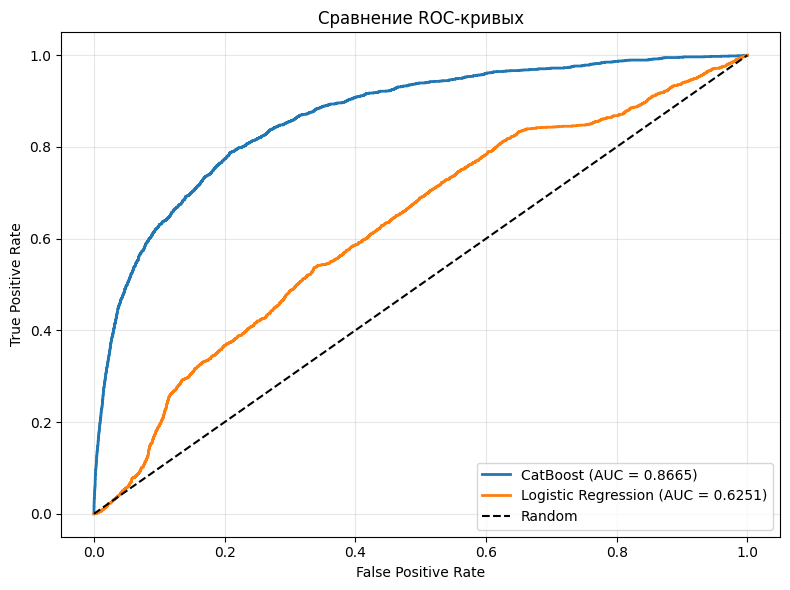

In [73]:
fpr_cat, tpr_cat, _ = roc_curve(y_test_raw, y_proba_cat)
fpr_lr, tpr_lr, _ = roc_curve(y_test_raw, y_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_score(y_test_raw, y_proba_cat):.4f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test_raw, y_proba_lr):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
cat_wins = 0
lr_wins = 0

if roc_auc_score(y_test_raw, y_proba_cat) > roc_auc_score(y_test_raw, y_proba_lr): cat_wins += 1
else: lr_wins += 1
if best_cat_profit > best_lr_profit: cat_wins += 1
else: lr_wins += 1

print(f"CatBoost: {cat_wins} балла | Logistic Regression: {lr_wins} балла")

if cat_wins > lr_wins:
    print(f"Рабочая модель: CatBoost")
else:
    print(f"Рабочая модель: Logistic Regression (для скоринговой карты)")

CatBoost: 2 балла | Logistic Regression: 0 балла
Рабочая модель: CatBoost


### Сравнение метрик

| Метрика | CatBoost | Logistic Regression |
|---|---|---|
| ROC-AUC | **0.8665** | 0.6251 |
| PR-AUC | **0.4165** | 0.0961 |
| Brier Score | **0.0485** | 0.2127 |
| Log Loss | **0.1764** | 0.6176 |
| Precision | **0.6151** | 0.1371 |
| Recall | 0.1908 | **0.2552** |

### Сравнение бизнес-метрик

| Модель | Порог | Прибыль | Одобрение | Bad Rate |
|---|---|---|---|---|
| **CatBoost** | 0.08 | **178 060 000 ₽** | 79.4% | 2.26% |
| Logistic Regression | 0.50 | 97 510 000 ₽ | 87.5% | 5.70% |

### Итог

| Модель | Баллы |
|---|---|
| CatBoost | **2** (ROC-AUC + Прибыль) |
| Logistic Regression | 0 |

### Выбор

**Рабочая модель: CatBoost**

**Обоснование:**
- ROC-AUC: 0.8665 против 0.6251
- Прибыль: 178 млн ₽ против 97 млн ₽ (разница 80 млн ₽)
- Bad Rate при оптимальном пороге: 2.26% против 5.70%
- CatBoost стабилен, не требует калибровки, показывает отличные бизнес-метрики

## Результаты проекта

### Что сделано

1. **Разведочный анализ данных (EDA):**
   - Выявлен дисбаланс классов (6.68% дефолтов)
   - Обнаружены аномалии: age = 0, выбросы в DebtRatio (до 329 664) и RevolvingUtilization (до 50 708)
   - Найдены замаскированные пропуски: MonthlyIncome (NaN = 19.82%, нули = 1.1%)
   - Проведен групповой анализ дефолтности по каждому признаку
   - Проверена временная структура данных (отсутствует)

2. **Предобработка данных:**
   - Удален технический столбец `Unnamed: 0` и строка с age = 0
   - Созданы бинарные индикаторы: `missing_income`, `missing_dependents`
   - Импутация MonthlyIncome: медиана для хороших клиентов, 0 для клиентов с просрочками
   - Импутация NumberOfDependents: медиана по возрастным группам
   - Винзоризация: RevolvingUtilization (99 перцентиль), DebtRatio (cap = 2.0)

3. **Feature Engineering:**
   - Создано 6 новых признаков: `delinquency_total`, `income_per_dependent`, `credit_per_age`, `age_group`, `any_delinquency`, `utilization_cat`
   - Лучший новый признак: `any_delinquency` (IV = 1.17)

4. **WOE-биннинг и Information Value:**
   - Отобрано 14 признаков с IV > 0.02
   - Топ-3: RevolvingUtilization (1.12), any_delinquency (1.17), delinquency_total (1.05)

5. **Обучение и сравнение моделей:**
   - Logistic Regression (WOE): ROC-AUC 0.8570
   - CatBoost (сырые данные): ROC-AUC 0.8651
   - XGBoost (сырые данные): ROC-AUC 0.8655
   - LightGBM (сырые данные): ROC-AUC 0.8650
   - Random Forest (сырые данные): ROC-AUC 0.8654
   - Альтернативный подход на сырых данных дал прирост +0.22% ROC-AUC

6. **Тюнинг гиперпараметров:**
   - GridSearchCV и RandomizedSearchCV для Logistic Regression
   - RandomizedSearchCV (30 итераций) для CatBoost
   - Итоговые параметры CatBoost: depth=4, iterations=250, learning_rate=0.1

7. **Кросс-валидация (5 фолдов):**
   - Logistic Regression: 0.8575 ± 0.0020
   - CatBoost: 0.8621 ± 0.0023

8. **Калибровка модели:**
   - CatBoost не требует калибровки (Brier Score = 0.0485 < 0.05)

9. **Оценка стабильности:**
   - **Кривая обучения:** Gap train/test = 0.0054, переобучения нет
   - **Бутстреп (1000 итераций):** 95% CI = [0.8580, 0.8743]
   - **PSI:** Все признаки < 0.001, дрейфа данных нет

10. **Оценка бизнес-метрик:**
    - Оптимальный порог: 0.08
    - Прибыль: 178 млн ₽ на тестовой выборке
    - Уровень одобрения: 79.4%
    - Bad Rate среди одобренных: 2.26%

### Достигнутые результаты

| Метрика | Значение |
|---|---|
| **Финальная модель** | CatBoost |
| **ROC-AUC** | **0.8665** |
| PR-AUC | 0.4165 |
| Brier Score | 0.0485 |
| Оптимальный порог | 0.08 |
| Прибыль | 178 060 000 ₽ |
| Уровень одобрения | 79.4% |
| Bad Rate | 2.26% |
| PSI | < 0.001 |
| 95% CI (бутстреп) | [0.8580, 0.8743] |